# Tabular-Only Logistic Regression - Mixed-All Multimodal Dataset

Logistic Regression on transaction features only from the multimodal mixed-all dataset.


**Part A** - Raw features 
**Part B** - Engineered features 

Threshold selection: **minimum expected cost** (FN × $50,000 + FP × $500).


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\src")

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

from tabular_baseline_utils import (
    build_preprocessor, build_logreg_pipeline, fit_model,
    evaluate_model, search_thresholds, compute_cost_table,
    evaluate_with_threshold, compute_expected_cost_from_cm,
    save_experiment_outputs,
)

PROJECT_ROOT = Path().resolve().parent
DATA_DIR     = PROJECT_ROOT / "data" / "processed"
RESULTS_ROOT = PROJECT_ROOT / "notebook" / "results" / "mm_tabular_logreg"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("Results root :", RESULTS_ROOT)


Project root : C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis
Results root : C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_logreg


In [2]:
import random

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)

SEED = 42
set_seed(SEED)
print(f"Random seed: {SEED}")


Random seed: 42


# Tabular-only LR baseline — multimodal dataset


In [3]:
train_df = pd.read_csv(DATA_DIR / "mm_train_mixed_all_group_test.csv")
val_df   = pd.read_csv(DATA_DIR / "mm_val_mixed_all_group_test.csv")
test_df  = pd.read_csv(DATA_DIR / "mm_test_mixed_all_group_test.csv")

from mm_tabular_utils import (
    TARGET_COL, RAW_COLS, FE_COLS,
    NUMERIC_RAW, NUMERIC_FE, CAT_COLS,
    engineer_features, validate_features, print_feature_summary,
)

print_feature_summary()
validate_features(RAW_COLS)
validate_features(FE_COLS)

print(f"\nTrain: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print("\nTrain class counts:")
print(train_df[TARGET_COL].value_counts())


Raw features  (8): ['tab_step', 'tab_amount', 'tab_oldbalanceOrg', 'tab_newbalanceOrig', 'tab_oldbalanceDest', 'tab_newbalanceDest', 'tab_isFlaggedFraud', 'tab_type']
FE  features  (13): ['tab_step', 'tab_amount', 'tab_oldbalanceOrg', 'tab_newbalanceOrig', 'tab_oldbalanceDest', 'tab_newbalanceDest', 'tab_isFlaggedFraud', 'tab_balance_delta_orig', 'tab_balance_delta_dest', 'tab_amount_ratio_orig', 'tab_amount_ratio_dest', 'tab_orig_balance_zeroed', 'tab_type']

Forbidden (excluded): ['combo_type', 'final_label', 'img_final_label', 'img_image_class', 'img_image_path', 'img_original_label', 'img_source_dataset', 'img_split', 'mm_id', 'split', 'tab_final_label', 'tab_isFraud']
Feature validation passed — 8 features, no leakage.
Feature validation passed — 13 features, no leakage.

Train: 7,182 | Val: 1,508 | Test: 1,474

Train class counts:
final_label
1    4594
0    2588
Name: count, dtype: int64


In [4]:
preprocessor_raw = build_preprocessor(NUMERIC_RAW, CAT_COLS)
preprocessor_raw


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['tab_step', 'tab_amount', 'tab_oldbalanceOrg',
                                  'tab_newbalanceOrig', 'tab_oldbalanceDest',
                                  'tab_newbalanceDest', 'tab_isFlaggedFraud']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['tab_type'])])

## Imbalance analysis

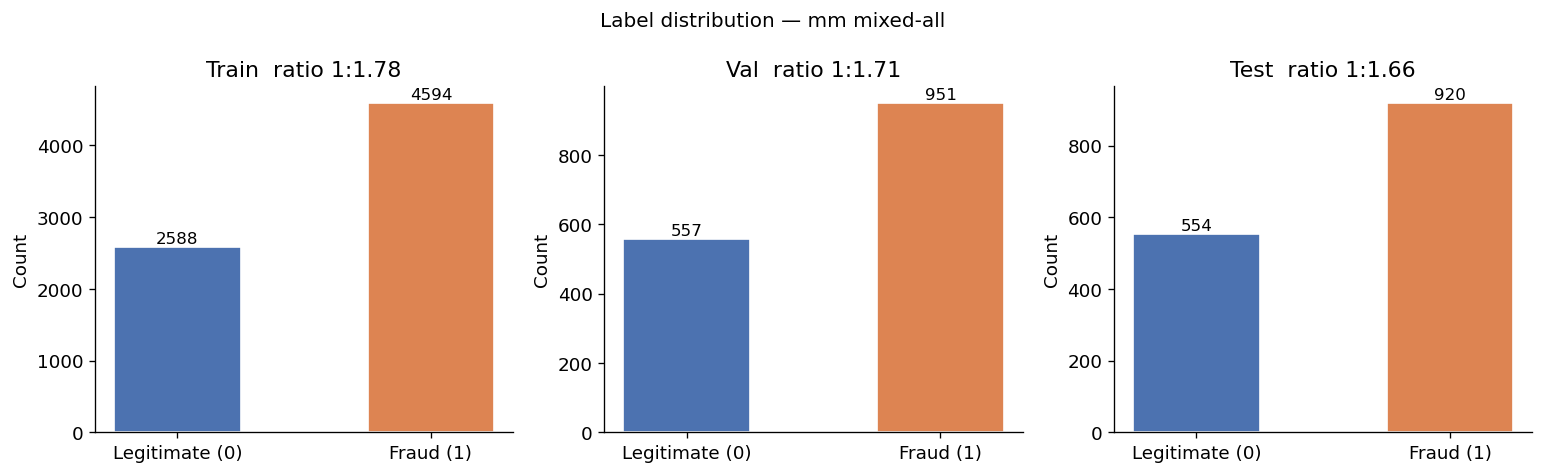

Label imbalance: 2588 legitimate vs 4594 fraud  (ratio 1:1.78)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, df) in zip(axes, [("Train",train_df),("Val",val_df),("Test",test_df)]):
    counts = df[TARGET_COL].value_counts().sort_index()
    bars = ax.bar(["Legitimate (0)","Fraud (1)"], counts.values,
                  color=["#4C72B0","#DD8452"], edgecolor="white", width=0.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                str(val), ha="center", va="bottom", fontsize=10)
    ratio = counts.get(1,0)/max(counts.get(0,1),1)
    ax.set_title(f"{name}  ratio 1:{ratio:.2f}"); ax.set_ylabel("Count")
    ax.spines[["top","right"]].set_visible(False)
fig.suptitle("Label distribution — mm mixed-all", fontsize=12)
fig.tight_layout(); plt.show()
n0 = (train_df[TARGET_COL]==0).sum(); n1 = (train_df[TARGET_COL]==1).sum()
print(f"Label imbalance: {n0} legitimate vs {n1} fraud  (ratio 1:{n1/n0:.2f})")


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter

def plot_model_diagnostics_pretty(cm, threshold_results, cost_df, model_name,
                                   fn_cost=50_000, fp_cost=500, save_path=None):
    """Identical to notebook 11 and 12."""
    cm = np.asarray(cm).astype(int)
    threshold_df   = threshold_results.sort_values("threshold")
    cost_df_sorted = cost_df.sort_values("threshold")
    best_row            = cost_df.loc[cost_df["expected_cost"].idxmin()]
    best_threshold      = float(best_row["threshold"])
    best_validation_cost = float(best_row["expected_cost"])
    tn, fp, fn, tp = cm.ravel()
    test_expected_cost = fn * fn_cost + fp * fp_cost

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), constrained_layout=True)
    fig.patch.set_facecolor("white")

    ax = axes[0]
    cm_for_color = np.maximum(cm, 1)
    norm = LogNorm(vmin=1, vmax=cm_for_color.max())
    im = ax.imshow(cm_for_color, cmap="Blues", norm=norm)
    ax.set_title("Tuned test confusion matrix", fontsize=12, pad=12)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Legit","Fraud"]); ax.set_yticklabels(["Legit","Fraud"])
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    for i in range(2):
        for j in range(2):
            value = cm[i,j]
            rgba  = im.cmap(norm(cm_for_color[i,j]))
            lum   = 0.299*rgba[0]+0.587*rgba[1]+0.114*rgba[2]
            ax.text(j, i, f"{value:,}", ha="center", va="center",
                    fontsize=11, fontweight="bold",
                    color="white" if lum < 0.45 else "#08306b")
    for sp in ax.spines.values(): sp.set_visible(False)

    ax = axes[1]
    ax.plot(threshold_df["threshold"], threshold_df["precision"], linewidth=2.2, label="Precision")
    ax.plot(threshold_df["threshold"], threshold_df["recall"],    linewidth=2.2, label="Recall")
    ax.plot(threshold_df["threshold"], threshold_df["f1"],        linewidth=2.2, label="F1")
    ax.axvline(best_threshold, linestyle="--", linewidth=1.8, color="black", alpha=0.7)
    ax.text(0.98, 0.95, f"Best threshold = {best_threshold:.2f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=10,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))
    ax.set_title("Validation metrics by threshold", fontsize=12, pad=12)
    ax.set_xlabel("Threshold"); ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.25); ax.legend(frameon=False, loc="lower left")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    ax = axes[2]
    ax.plot(cost_df_sorted["threshold"], cost_df_sorted["expected_cost"],
            linewidth=2.2, marker="o", markersize=4)
    ax.axvline(best_threshold, linestyle="--", linewidth=1.8, color="black", alpha=0.7)
    ax.scatter(best_threshold, best_validation_cost, s=80, color="black", zorder=5)
    ax.annotate(f"Min cost: ${best_validation_cost/1_000_000:.2f}M",
                xy=(best_threshold, best_validation_cost), xytext=(18,18),
                textcoords="offset points", fontsize=10,
                arrowprops=dict(arrowstyle="->", linewidth=1, color="black"),
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.85))
    ax.set_title("Validation expected cost by threshold", fontsize=12, pad=12)
    ax.set_xlabel("Threshold"); ax.set_ylabel("Expected cost")
    ax.grid(True, alpha=0.25)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.2f}M"))
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    fig.suptitle(f"{model_name} diagnostics | Tuned test cost: ${test_expected_cost/1_000_000:.2f}M",
                 fontsize=15, fontweight="bold")
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


---
## Part A — Raw features
Same 7 transaction variables as notebook 11 (direct LR comparison).

In [7]:
X_train_raw = train_df[RAW_COLS]; y_train = train_df[TARGET_COL]
X_val_raw   = val_df[RAW_COLS];   y_val   = val_df[TARGET_COL]
X_test_raw  = test_df[RAW_COLS];  y_test  = test_df[TARGET_COL]

print("Features:", list(RAW_COLS))
print("X_train shape:", X_train_raw.shape)
print("X_val   shape:", X_val_raw.shape)
print("X_test  shape:", X_test_raw.shape)


Features: ['tab_step', 'tab_amount', 'tab_oldbalanceOrg', 'tab_newbalanceOrig', 'tab_oldbalanceDest', 'tab_newbalanceDest', 'tab_isFlaggedFraud', 'tab_type']
X_train shape: (7182, 8)
X_val   shape: (1508, 8)
X_test  shape: (1474, 8)


## 1. LR — A_none

Standard LR with no imbalance correction. Baseline.

In [8]:
import joblib

results_dir = RESULTS_ROOT / "A_none"
results_dir.mkdir(parents=True, exist_ok=True)

model_path    = results_dir / "A_none_model.joblib"
FORCE_RETRAIN = False

print("Checking model path:")
print(model_path)
print("Model exists:", model_path.exists())

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved LR — A_none model...")
    model_a_none = joblib.load(model_path)
    print("Model loaded successfully.")
else:
    print("Saved model not found. Training LR — A_none model...")
    preprocessor_raw = build_preprocessor(NUMERIC_RAW, CAT_COLS)
    model_a_none = build_logreg_pipeline(preprocessor_raw, imbalance_method="none")
    model_a_none = fit_model(model_a_none, X_train_raw, y_train)
    joblib.dump(model_a_none, model_path)
    print("Training finished and model saved to:", model_path)


Checking model path:
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_logreg\A_none\A_none_model.joblib
Model exists: True
Already trained. Loading saved LR — A_none model...
Model loaded successfully.


In [9]:
val_metrics_A_none,  val_cm_A_none  = evaluate_model(model_a_none, X_val_raw,  y_val,  split_name="validation_A_none")
test_metrics_A_none, test_cm_A_none = evaluate_model(model_a_none, X_test_raw, y_test, split_name="test_A_none")



=== VALIDATION_A_NONE ===
accuracy: 0.680371
precision: 0.728780
recall: 0.785489
f1: 0.756073
roc_auc: 0.767932
pr_auc: 0.880144

Confusion matrix:
[[279 278]
 [204 747]]

Classification report:
              precision    recall  f1-score   support

           0     0.5776    0.5009    0.5365       557
           1     0.7288    0.7855    0.7561       951

    accuracy                         0.6804      1508
   macro avg     0.6532    0.6432    0.6463      1508
weighted avg     0.6730    0.6804    0.6750      1508


=== TEST_A_NONE ===
accuracy: 0.683853
precision: 0.732582
recall: 0.777174
f1: 0.754219
roc_auc: 0.781173
pr_auc: 0.884339

Confusion matrix:
[[293 261]
 [205 715]]

Classification report:
              precision    recall  f1-score   support

           0     0.5884    0.5289    0.5570       554
           1     0.7326    0.7772    0.7542       920

    accuracy                         0.6839      1474
   macro avg     0.6605    0.6530    0.6556      1474
weighted avg 

### Multimodal-subset Logistic Regression: A_none baseline

The A_none Logistic Regression model gives moderate performance on the multimodal tabular subset. The validation and test results are very similar, which suggests that the model generalizes consistently.

On the test set, the model achieves an accuracy of 0.6839, precision of 0.7326, recall of 0.7772, and F1-score of 0.7542 for the fraud class. This means that the model detects around 77.7% of fraud cases, but it also produces many false positives.

The confusion matrix shows that the model correctly detects 715 fraud cases and misses 205. It also correctly identifies 293 legitimate cases, while incorrectly flagging 261 legitimate cases as fraud.

The ROC-AUC is 0.7812 and PR-AUC is 0.8843, showing that the model has some ability to rank fraud cases above legitimate cases. However, the overall separation is limited. The macro F1-score is only 0.6556, which shows that performance on the legitimate class is much weaker than on the fraud class.



### Threshold tuning for LR A_none

Cost-based threshold tuning on the validation set.

In [10]:
threshold_results_A_none = search_thresholds(model_a_none, X_val_raw, y_val)
print(threshold_results_A_none)


    threshold  precision    recall        f1  predicted_fraud
0        0.10   0.630392  0.998948  0.772986             1507
1        0.15   0.630392  0.998948  0.772986             1507
2        0.20   0.630319  0.996845  0.772301             1504
3        0.25   0.630493  0.995794  0.772116             1502
4        0.30   0.631791  0.990536  0.771499             1491
5        0.35   0.638209  0.958991  0.766387             1429
6        0.40   0.665886  0.896951  0.764337             1281
7        0.45   0.707539  0.819138  0.759259             1101
8        0.50   0.728780  0.785489  0.756073             1025
9        0.55   0.766926  0.726604  0.746220              901
10       0.60   0.822134  0.656151  0.729825              759
11       0.65   0.904459  0.597266  0.719443              628
12       0.70   0.910683  0.546793  0.683311              571
13       0.75   0.944785  0.485804  0.641667              489
14       0.80   0.985294  0.422713  0.591611              408
15      

In [11]:
cost_df_A_none = compute_cost_table(threshold_results_A_none, y_val)
print(cost_df_A_none.head())


   threshold   tp   fp  fn  tn  precision    recall        f1  \
0       0.10  950  557   1   0   0.630392  0.998948  0.772986   
1       0.15  950  557   1   0   0.630392  0.998948  0.772986   
2       0.20  948  556   3   1   0.630319  0.996845  0.772301   
3       0.25  947  555   4   2   0.630493  0.995794  0.772116   
4       0.30  942  549   9   8   0.631791  0.990536  0.771499   

   predicted_fraud  expected_cost  
0             1507         328500  
1             1507         328500  
2             1504         428000  
3             1502         477500  
4             1491         724500  


Threshold tuning was applied to the A_none Logistic Regression model on the validation set. The lowest expected validation cost is achieved at threshold 0.10.

At this threshold, the model detects 950 fraud cases and misses only 1. However, it also produces 557 false positives and correctly identifies no legitimate cases. This means the model becomes extremely aggressive and predicts almost all observations as fraud.

The expected validation cost at threshold 0.10 is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 1 × $50,000 + 557 × $500  
Expected cost = $50,000 + $278,500  
Expected cost = $328,500

In [12]:
val_cost_A_none      = compute_expected_cost_from_cm(val_cm_A_none)
default_validation_cost = val_cost_A_none["expected_cost"]
best_validation_cost    = cost_df_A_none.iloc[0]["expected_cost"]
cost_reduction          = default_validation_cost - best_validation_cost

print(f"Default validation cost:    ${default_validation_cost:,.0f}")
print(f"Best tuned validation cost: ${best_validation_cost:,.0f}")
print(f"Cost reduction:             ${cost_reduction:,.0f}")


Default validation cost:    $10,339,000
Best tuned validation cost: $328,500
Cost reduction:             $10,010,500


### Tuned threshold results for LR A_none

In [13]:
best_threshold_A_none = float(cost_df_A_none.iloc[0]["threshold"])
best_threshold_A_none


0.1

In [14]:
tuned_metrics_A_none, tuned_cm_A_none = evaluate_with_threshold(
    model_a_none, X_test_raw, y_test, best_threshold_A_none)
cost_summary_A_none = compute_expected_cost_from_cm(tuned_cm_A_none)
print(cost_summary_A_none)



Tuned threshold: 0.1
Precision: 0.6245756958587916
Recall: 1.0
F1: 0.768909318846636

Confusion matrix:
[[  1 553]
 [  0 920]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.0018    0.0036       554
           1     0.6246    1.0000    0.7689       920

    accuracy                         0.6248      1474
   macro avg     0.8123    0.5009    0.3863      1474
weighted avg     0.7657    0.6248    0.4813      1474

{'tp': 920, 'fp': 553, 'fn': 0, 'tn': 1, 'expected_cost': 276500}


After cost-based threshold tuning, the selected threshold for the A_none Logistic Regression model was 0.10. At this threshold, the model detects all 920 fraud cases in the test set, so recall reaches 1.0000.

However, the confusion matrix shows that the model almost always predicts fraud. It correctly identifies only 1 legitimate case and incorrectly flags 553 legitimate cases as fraud. This means the model achieves zero false negatives, but it nearly loses the ability to recognize legitimate transactions.

The expected test cost is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 0 × $50,000 + 553 × $500  
Expected cost = $276,500

In [15]:
save_experiment_outputs(
    results_dir=results_dir,
    model=model_a_none,
    val_metrics=val_metrics_A_none,
    test_metrics=test_metrics_A_none,
    val_cm=val_cm_A_none,
    test_cm=test_cm_A_none,
    threshold_results=threshold_results_A_none,
    cost_df=cost_df_A_none,
    tuned_metrics=tuned_metrics_A_none,
    tuned_cm=tuned_cm_A_none,
    prefix="A_none",
)
print("Saved outputs to:", results_dir)


Saved outputs to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_logreg\A_none


In [16]:
saved_files = sorted([p.name for p in results_dir.glob("*")])
saved_files


['A_none_cost_results.csv',
 'A_none_metrics_summary.csv',
 'A_none_model.joblib',
 'A_none_test_confusion_matrix.csv',
 'A_none_test_metrics.json',
 'A_none_threshold_results.csv',
 'A_none_tuned_test_confusion_matrix.csv',
 'A_none_tuned_test_metrics.json',
 'A_none_validation_confusion_matrix.csv',
 'A_none_validation_metrics.json']

## 2. LR - A_weight

LR with `class_weight='balanced'` - mirrors LR class_weight from notebook 11.

In [17]:
import joblib

results_dir = RESULTS_ROOT / "A_weight"
results_dir.mkdir(parents=True, exist_ok=True)

model_path    = results_dir / "A_weight_model.joblib"
FORCE_RETRAIN = False

print("Checking model path:")
print(model_path)
print("Model exists:", model_path.exists())

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved LR — A_weight model...")
    model_a_weight = joblib.load(model_path)
    print("Model loaded successfully.")
else:
    print("Saved model not found. Training LR — A_weight model...")
    preprocessor_raw = build_preprocessor(NUMERIC_RAW, CAT_COLS)
    model_a_weight = build_logreg_pipeline(preprocessor_raw, imbalance_method="class_weight")
    model_a_weight = fit_model(model_a_weight, X_train_raw, y_train)
    joblib.dump(model_a_weight, model_path)
    print("Training finished and model saved to:", model_path)


Checking model path:
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_logreg\A_weight\A_weight_model.joblib
Model exists: True
Already trained. Loading saved LR — A_weight model...
Model loaded successfully.


In [18]:
val_metrics_A_weight,  val_cm_A_weight  = evaluate_model(model_a_weight, X_val_raw,  y_val,  split_name="validation_A_weight")
test_metrics_A_weight, test_cm_A_weight = evaluate_model(model_a_weight, X_test_raw, y_test, split_name="test_A_weight")



=== VALIDATION_A_WEIGHT ===
accuracy: 0.707560
precision: 0.887538
recall: 0.614090
f1: 0.725917
roc_auc: 0.769373
pr_auc: 0.881358

Confusion matrix:
[[483  74]
 [367 584]]

Classification report:
              precision    recall  f1-score   support

           0     0.5682    0.8671    0.6866       557
           1     0.8875    0.6141    0.7259       951

    accuracy                         0.7076      1508
   macro avg     0.7279    0.7406    0.7062      1508
weighted avg     0.7696    0.7076    0.7114      1508


=== TEST_A_WEIGHT ===
accuracy: 0.713704
precision: 0.895238
recall: 0.613043
f1: 0.727742
roc_auc: 0.781086
pr_auc: 0.885036

Confusion matrix:
[[488  66]
 [356 564]]

Classification report:
              precision    recall  f1-score   support

           0     0.5782    0.8809    0.6981       554
           1     0.8952    0.6130    0.7277       920

    accuracy                         0.7137      1474
   macro avg     0.7367    0.7470    0.7129      1474
weighted 



 The A_weight Logistic Regression model is more conservative than A_none. It produces fewer false positives, but it also misses more fraud cases.

On the test set, the model achieves accuracy of 0.7137, precision of 0.8952, recall of 0.6130, and F1-score of 0.7277 for the fraud class. The high precision means that when the model predicts fraud, it is usually correct. However, the lower recall shows that it misses many fraud cases.

The confusion matrix shows this trade-off clearly. The model correctly detects 564 fraud cases, but misses 356. It also correctly identifies 488 legitimate cases and incorrectly flags only 66 legitimate cases as fraud.

Compared with A_none, the weighted model improves legitimate-class detection and reduces false positives. However, it sacrifices fraud recall. Since fraud detection is cost-sensitive, this lower recall may be problematic because missed fraud cases are expensive.



### Threshold tuning for LR A_weight

Cost-based threshold tuning on the validation set.

In [19]:
threshold_results_A_weight = search_thresholds(model_a_weight, X_val_raw, y_val)
print(threshold_results_A_weight)


    threshold  precision    recall        f1  predicted_fraud
0        0.10   0.630565  0.997897  0.772801             1505
1        0.15   0.630493  0.995794  0.772116             1502
2        0.20   0.632571  0.988433  0.771440             1486
3        0.25   0.648175  0.933754  0.765187             1370
4        0.30   0.691050  0.844374  0.760057             1162
5        0.35   0.722115  0.789695  0.754395             1040
6        0.40   0.757250  0.741325  0.749203              931
7        0.45   0.810742  0.666667  0.731679              782
8        0.50   0.887538  0.614090  0.725917              658
9        0.55   0.904682  0.568875  0.698515              598
10       0.60   0.930275  0.533123  0.677807              545
11       0.65   0.969828  0.473186  0.636042              464
12       0.70   0.985472  0.427971  0.596774              413
13       0.75   0.994580  0.385910  0.556061              369
14       0.80   0.996904  0.338591  0.505495              323
15      

In [20]:
cost_df_A_weight = compute_cost_table(threshold_results_A_weight, y_val)
print(cost_df_A_weight.head())


   threshold   tp   fp   fn   tn  precision    recall        f1  \
0       0.10  949  556    2    1   0.630565  0.997897  0.772801   
1       0.15  947  555    4    2   0.630493  0.995794  0.772116   
2       0.20  940  546   11   11   0.632571  0.988433  0.771440   
3       0.25  888  482   63   75   0.648175  0.933754  0.765187   
4       0.30  803  359  148  198   0.691050  0.844374  0.760057   

   predicted_fraud  expected_cost  
0             1505         378000  
1             1502         477500  
2             1486         823000  
3             1370        3391000  
4             1162        7579500  


Threshold tuning was applied to the A_weight Logistic Regression model on the validation set. The lowest expected validation cost is reached at threshold 0.10.

At this threshold, the model detects 949 fraud cases and misses only 2. However, it also produces 556 false positives and correctly identifies only 1 legitimate case. This means that cost-based tuning makes the model very aggressive, similar to the A_none model.

The expected validation cost at threshold 0.10 is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 2 × $50,000 + 556 × $500  
Expected cost = $100,000 + $278,000  
Expected cost = $378,000

In [21]:
val_cost_A_weight      = compute_expected_cost_from_cm(val_cm_A_weight)
default_validation_cost = val_cost_A_weight["expected_cost"]
best_validation_cost    = cost_df_A_weight.iloc[0]["expected_cost"]
cost_reduction          = default_validation_cost - best_validation_cost

print(f"Default validation cost:    ${default_validation_cost:,.0f}")
print(f"Best tuned validation cost: ${best_validation_cost:,.0f}")
print(f"Cost reduction:             ${cost_reduction:,.0f}")


Default validation cost:    $18,387,000
Best tuned validation cost: $378,000
Cost reduction:             $18,009,000


### Tuned threshold results for LR A_weight

In [22]:
best_threshold_A_weight = float(cost_df_A_weight.iloc[0]["threshold"])
best_threshold_A_weight


0.1

In [23]:
tuned_metrics_A_weight, tuned_cm_A_weight = evaluate_with_threshold(
    model_a_weight, X_test_raw, y_test, best_threshold_A_weight)
cost_summary_A_weight = compute_expected_cost_from_cm(tuned_cm_A_weight)
print(cost_summary_A_weight)



Tuned threshold: 0.1
Precision: 0.625
Recall: 1.0
F1: 0.7692307692307693

Confusion matrix:
[[  2 552]
 [  0 920]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.0036    0.0072       554
           1     0.6250    1.0000    0.7692       920

    accuracy                         0.6255      1474
   macro avg     0.8125    0.5018    0.3882      1474
weighted avg     0.7659    0.6255    0.4828      1474

{'tp': 920, 'fp': 552, 'fn': 0, 'tn': 2, 'expected_cost': 276000}


After cost-based threshold tuning, the selected threshold for the A_weight Logistic Regression model was 0.10. At this threshold, the model detects all 920 fraud cases in the test set, so recall reaches 1.0000.

However, the model also becomes extremely aggressive. It correctly identifies only 2 legitimate cases and incorrectly flags 552 legitimate cases as fraud. This means that the model almost always predicts fraud.

The expected test cost is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 0 × $50,000 + 552 × $500  
Expected cost = $276,000

Although this is a low expected cost, the macro F1-score is only 0.3882 because the model performs very poorly on the legitimate class. Therefore, the cost-tuned A_weight result should be interpreted carefully. It minimizes missed fraud, but it does so by sacrificing almost all legitimate-class detection.

In [24]:
save_experiment_outputs(
    results_dir=results_dir,
    model=model_a_weight,
    val_metrics=val_metrics_A_weight,
    test_metrics=test_metrics_A_weight,
    val_cm=val_cm_A_weight,
    test_cm=test_cm_A_weight,
    threshold_results=threshold_results_A_weight,
    cost_df=cost_df_A_weight,
    tuned_metrics=tuned_metrics_A_weight,
    tuned_cm=tuned_cm_A_weight,
    prefix="A_weight",
)
print("Saved outputs to:", results_dir)


Saved outputs to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_logreg\A_weight


In [25]:
saved_files = sorted([p.name for p in results_dir.glob("*")])
saved_files


['A_weight_cost_results.csv',
 'A_weight_metrics_summary.csv',
 'A_weight_model.joblib',
 'A_weight_test_confusion_matrix.csv',
 'A_weight_test_metrics.json',
 'A_weight_threshold_results.csv',
 'A_weight_tuned_test_confusion_matrix.csv',
 'A_weight_tuned_test_metrics.json',
 'A_weight_validation_confusion_matrix.csv',
 'A_weight_validation_metrics.json']

## 3. LR — A_smote

LR with SMOTE (strategy=1.0) — mirrors LR SMOTE from notebook 11.

In [26]:
import joblib

results_dir = RESULTS_ROOT / "A_smote"
results_dir.mkdir(parents=True, exist_ok=True)

model_path    = results_dir / "A_smote_model.joblib"
FORCE_RETRAIN = False

print("Checking model path:")
print(model_path)
print("Model exists:", model_path.exists())

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved LR — A_smote model...")
    model_a_smote = joblib.load(model_path)
    print("Model loaded successfully.")
else:
    print("Saved model not found. Training LR — A_smote model...")
    preprocessor_raw = build_preprocessor(NUMERIC_RAW, CAT_COLS)
    model_a_smote = build_logreg_pipeline(preprocessor_raw, imbalance_method="smote")
    model_a_smote = fit_model(model_a_smote, X_train_raw, y_train)
    joblib.dump(model_a_smote, model_path)
    print("Training finished and model saved to:", model_path)


Checking model path:
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_logreg\A_smote\A_smote_model.joblib
Model exists: True
Already trained. Loading saved LR — A_smote model...
Model loaded successfully.


In [27]:
val_metrics_A_smote,  val_cm_A_smote  = evaluate_model(model_a_smote, X_val_raw,  y_val,  split_name="validation_A_smote")
test_metrics_A_smote, test_cm_A_smote = evaluate_model(model_a_smote, X_test_raw, y_test, split_name="test_A_smote")



=== VALIDATION_A_SMOTE ===
accuracy: 0.705570
precision: 0.881203
recall: 0.616193
f1: 0.725248
roc_auc: 0.769680
pr_auc: 0.881904

Confusion matrix:
[[478  79]
 [365 586]]

Classification report:
              precision    recall  f1-score   support

           0     0.5670    0.8582    0.6829       557
           1     0.8812    0.6162    0.7252       951

    accuracy                         0.7056      1508
   macro avg     0.7241    0.7372    0.7041      1508
weighted avg     0.7652    0.7056    0.7096      1508


=== TEST_A_SMOTE ===
accuracy: 0.715739
precision: 0.893250
recall: 0.618478
f1: 0.730893
roc_auc: 0.781971
pr_auc: 0.885883

Confusion matrix:
[[486  68]
 [351 569]]

Classification report:
              precision    recall  f1-score   support

           0     0.5806    0.8773    0.6988       554
           1     0.8932    0.6185    0.7309       920

    accuracy                         0.7157      1474
   macro avg     0.7369    0.7479    0.7148      1474
weighted av

The A_SMOTE Logistic Regression model performs similarly to A_weight. It is more conservative than A_none: it produces fewer false positives, but it also misses more fraud cases.

On the test set, the model achieves accuracy of 0.7157, precision of 0.8932, recall of 0.6185, and F1-score of 0.7309 for the fraud class. The high precision means that most predicted fraud cases are correct. However, recall is relatively low, so the model still misses many fraud cases.

The confusion matrix shows that the model correctly detects 569 fraud cases and misses 351. It also correctly identifies 486 legitimate cases and incorrectly flags 68 legitimate cases as fraud.

Compared with A_none, SMOTE improves legitimate-class detection and reduces false positives, but it lowers fraud recall. Compared with A_weigh, the results are very similar, with slightly higher fraud recall and F1-score.


### Threshold tuning for LR A_smote

Cost-based threshold tuning on the validation set.

In [28]:
threshold_results_A_smote = search_thresholds(model_a_smote, X_val_raw, y_val)
print(threshold_results_A_smote)


    threshold  precision    recall        f1  predicted_fraud
0        0.10   0.630319  0.996845  0.772301             1504
1        0.15   0.631333  0.995794  0.772746             1500
2        0.20   0.633356  0.986330  0.771382             1481
3        0.25   0.652110  0.926393  0.765421             1351
4        0.30   0.694107  0.842271  0.761045             1154
5        0.35   0.725962  0.793901  0.758413             1040
6        0.40   0.757511  0.742376  0.749867              932
7        0.45   0.809645  0.670873  0.733755              788
8        0.50   0.881203  0.616193  0.725248              665
9        0.55   0.902479  0.574132  0.701799              605
10       0.60   0.925319  0.534175  0.677333              549
11       0.65   0.972043  0.475289  0.638418              465
12       0.70   0.990431  0.435331  0.604821              418
13       0.75   0.994681  0.393270  0.563677              376
14       0.80   0.996951  0.343849  0.511337              328
15      

In [29]:
cost_df_A_smote = compute_cost_table(threshold_results_A_smote, y_val)
print(cost_df_A_smote.head())


   threshold   tp   fp   fn   tn  precision    recall        f1  \
0       0.10  948  556    3    1   0.630319  0.996845  0.772301   
1       0.15  947  553    4    4   0.631333  0.995794  0.772746   
2       0.20  938  543   13   14   0.633356  0.986330  0.771382   
3       0.25  881  470   70   87   0.652110  0.926393  0.765421   
4       0.30  801  353  150  204   0.694107  0.842271  0.761045   

   predicted_fraud  expected_cost  
0             1504         428000  
1             1500         476500  
2             1481         921500  
3             1351        3735000  
4             1154        7676500  




Threshold tuning was applied to the A_SMOTE Logistic Regression model on the validation set. The lowest expected validation cost is reached at threshold 0.10.

At this threshold, the model detects 948 fraud cases and misses only 3. However, it also produces 556 false positives and correctly identifies only 1 legitimate case. This means that the model becomes very aggressive and predicts almost all observations as fraud.

The expected validation cost at threshold 0.10 is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 3 × $50,000 + 556 × $500  
Expected cost = $150,000 + $278,000  
Expected cost = $428,000

Although this threshold gives the lowest expected cost, it almost completely removes legitimate-class detection. 

In [30]:
val_cost_A_smote      = compute_expected_cost_from_cm(val_cm_A_smote)
default_validation_cost = val_cost_A_smote["expected_cost"]
best_validation_cost    = cost_df_A_smote.iloc[0]["expected_cost"]
cost_reduction          = default_validation_cost - best_validation_cost

print(f"Default validation cost:    ${default_validation_cost:,.0f}")
print(f"Best tuned validation cost: ${best_validation_cost:,.0f}")
print(f"Cost reduction:             ${cost_reduction:,.0f}")


Default validation cost:    $18,289,500
Best tuned validation cost: $428,000
Cost reduction:             $17,861,500


### Tuned threshold results for LR A_smote

In [31]:
best_threshold_A_smote = float(cost_df_A_smote.iloc[0]["threshold"])
best_threshold_A_smote


0.1

In [32]:
tuned_metrics_A_smote, tuned_cm_A_smote = evaluate_with_threshold(
    model_a_smote, X_test_raw, y_test, best_threshold_A_smote)
cost_summary_A_smote = compute_expected_cost_from_cm(tuned_cm_A_smote)
print(cost_summary_A_smote)



Tuned threshold: 0.1
Precision: 0.625
Recall: 1.0
F1: 0.7692307692307693

Confusion matrix:
[[  2 552]
 [  0 920]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.0036    0.0072       554
           1     0.6250    1.0000    0.7692       920

    accuracy                         0.6255      1474
   macro avg     0.8125    0.5018    0.3882      1474
weighted avg     0.7659    0.6255    0.4828      1474

{'tp': 920, 'fp': 552, 'fn': 0, 'tn': 2, 'expected_cost': 276000}




After cost-based threshold tuning, the selected threshold for the A_SMOTE Logistic Regression model was 0.10. At this threshold, the model detects all 920 fraud cases in the test set, so recall reaches 1.0000.

However, the model becomes extremely aggressive. It correctly identifies only 2 legitimate cases and incorrectly flags 552 legitimate cases as fraud. This means that almost every observation is classified as fraud.

The expected test cost is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 0 × $50,000 + 552 × $500  
Expected cost = $276,000

Although this is a low expected cost, the macro F1-score is only 0.3882 because the model performs very poorly on the legitimate class. Therefore, the cost-tuned A_SMOTE result should be interpreted carefully. It minimizes missed fraud, but it almost completely sacrifices legitimate-class detection.

In [33]:
save_experiment_outputs(
    results_dir=results_dir,
    model=model_a_smote,
    val_metrics=val_metrics_A_smote,
    test_metrics=test_metrics_A_smote,
    val_cm=val_cm_A_smote,
    test_cm=test_cm_A_smote,
    threshold_results=threshold_results_A_smote,
    cost_df=cost_df_A_smote,
    tuned_metrics=tuned_metrics_A_smote,
    tuned_cm=tuned_cm_A_smote,
    prefix="A_smote",
)
print("Saved outputs to:", results_dir)


Saved outputs to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_logreg\A_smote


In [34]:
saved_files = sorted([p.name for p in results_dir.glob("*")])
saved_files


['A_smote_cost_results.csv',
 'A_smote_metrics_summary.csv',
 'A_smote_model.joblib',
 'A_smote_test_confusion_matrix.csv',
 'A_smote_test_metrics.json',
 'A_smote_threshold_results.csv',
 'A_smote_tuned_test_confusion_matrix.csv',
 'A_smote_tuned_test_metrics.json',
 'A_smote_validation_confusion_matrix.csv',
 'A_smote_validation_metrics.json']

## Comparison - Part A - raw features

In [37]:
import pandas as pd

comparison_a = pd.DataFrame([
    {
        "model": "A_none",
        "val_f1": val_metrics_A_none["f1"],
        "val_roc_auc": val_metrics_A_none["roc_auc"],
        "val_pr_auc": val_metrics_A_none["pr_auc"],
        "test_f1": test_metrics_A_none["f1"],
        "test_roc_auc": test_metrics_A_none["roc_auc"],
        "test_pr_auc": test_metrics_A_none["pr_auc"],
        "best_threshold": best_threshold_A_none,
        "tuned_test_precision": tuned_metrics_A_none["precision"],
        "tuned_test_recall": tuned_metrics_A_none["recall"],
        "tuned_test_f1": tuned_metrics_A_none["f1"],
        "tuned_expected_cost": cost_summary_A_none["expected_cost"],
    },
    {
        "model": "A_weight",
        "val_f1": val_metrics_A_weight["f1"],
        "val_roc_auc": val_metrics_A_weight["roc_auc"],
        "val_pr_auc": val_metrics_A_weight["pr_auc"],
        "test_f1": test_metrics_A_weight["f1"],
        "test_roc_auc": test_metrics_A_weight["roc_auc"],
        "test_pr_auc": test_metrics_A_weight["pr_auc"],
        "best_threshold": best_threshold_A_weight,
        "tuned_test_precision": tuned_metrics_A_weight["precision"],
        "tuned_test_recall": tuned_metrics_A_weight["recall"],
        "tuned_test_f1": tuned_metrics_A_weight["f1"],
        "tuned_expected_cost": cost_summary_A_weight["expected_cost"],
    },
    {
        "model": "A_smote",
        "val_f1": val_metrics_A_smote["f1"],
        "val_roc_auc": val_metrics_A_smote["roc_auc"],
        "val_pr_auc": val_metrics_A_smote["pr_auc"],
        "test_f1": test_metrics_A_smote["f1"],
        "test_roc_auc": test_metrics_A_smote["roc_auc"],
        "test_pr_auc": test_metrics_A_smote["pr_auc"],
        "best_threshold": best_threshold_A_smote,
        "tuned_test_precision": tuned_metrics_A_smote["precision"],
        "tuned_test_recall": tuned_metrics_A_smote["recall"],
        "tuned_test_f1": tuned_metrics_A_smote["f1"],
        "tuned_expected_cost": cost_summary_A_smote["expected_cost"],
    },
])

comparison_a


,model,val_f1,val_roc_auc,val_pr_auc,test_f1,test_roc_auc,test_pr_auc,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
0,A_none,0.756073,0.767932,0.880144,0.754219,0.781173,0.884339,0.1,0.624576,1.0,0.768909,276500
1,A_weight,0.725917,0.769373,0.881358,0.727742,0.781086,0.885036,0.1,0.625000,1.0,0.769231,276000
2,A_smote,0.725248,0.769680,0.881904,0.730893,0.781971,0.885883,0.1,0.625000,1.0,0.769231,276000


In [38]:
comparison_a.sort_values("tuned_expected_cost")[
    ["model","best_threshold","tuned_test_precision",
     "tuned_test_recall","tuned_test_f1","tuned_expected_cost"]
]


,model,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
1,A_weight,0.1,0.625000,1.0,0.769231,276000
2,A_smote,0.1,0.625000,1.0,0.769231,276000
0,A_none,0.1,0.624576,1.0,0.768909,276500


## Comparison bar chart - Part A - raw features

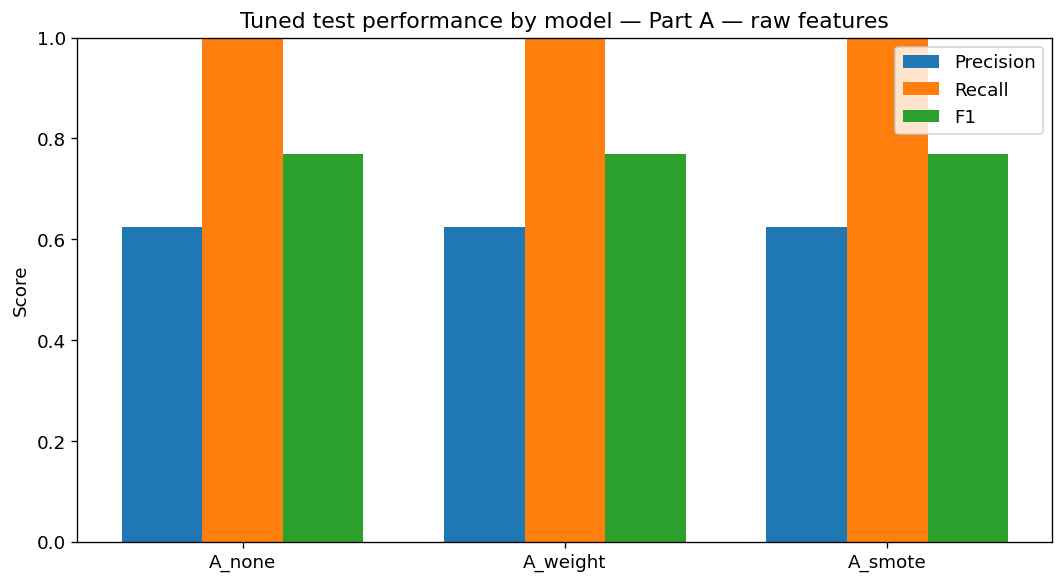

In [39]:
import numpy as np, matplotlib.pyplot as plt
metrics_plot  = ["tuned_test_precision","tuned_test_recall","tuned_test_f1"]
metric_labels = ["Precision","Recall","F1"]
x = np.arange(len(comparison_a["model"])); width = 0.25
plt.figure(figsize=(9, 5))
for i, metric in enumerate(metrics_plot):
    plt.bar(x + i*width, comparison_a[metric], width, label=metric_labels[i])
plt.xticks(x + width, comparison_a["model"])
plt.ylabel("Score")
plt.title("Tuned test performance by model — Part A — raw features")
plt.legend(); plt.ylim(0, 1); plt.tight_layout(); plt.show()


## Expected cost comparison - Part A - raw features

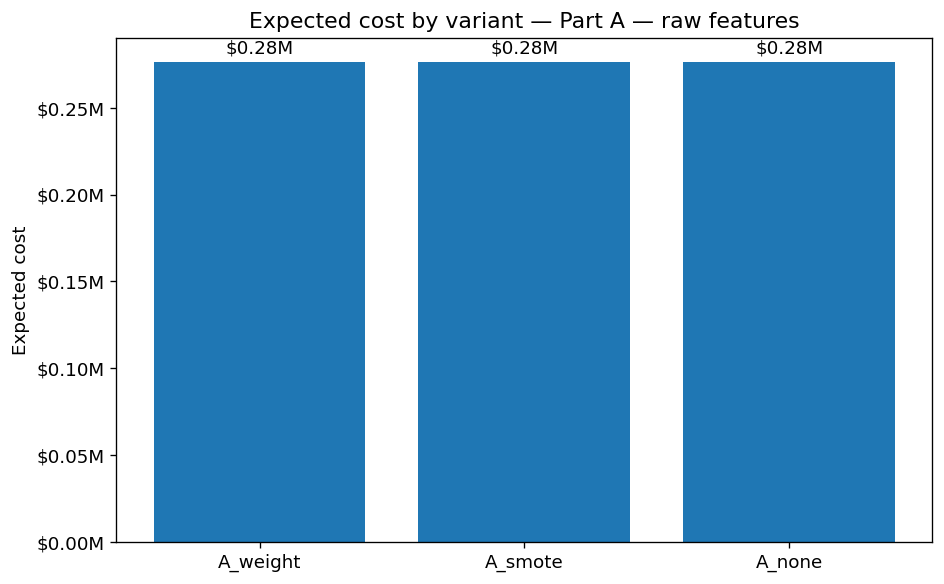

In [40]:
from matplotlib.ticker import FuncFormatter
cost_plot_df = comparison_a.sort_values("tuned_expected_cost")
plt.figure(figsize=(8, 5))
bars = plt.bar(cost_plot_df["model"], cost_plot_df["tuned_expected_cost"])
plt.title("Expected cost by variant — Part A — raw features")
plt.ylabel("Expected cost")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.2f}M"))
plt.bar_label(bars,
    labels=[f"${v/1_000_000:.2f}M" for v in cost_plot_df["tuned_expected_cost"]],
    padding=3)
plt.tight_layout(); plt.show()


## Threshold performance plot 

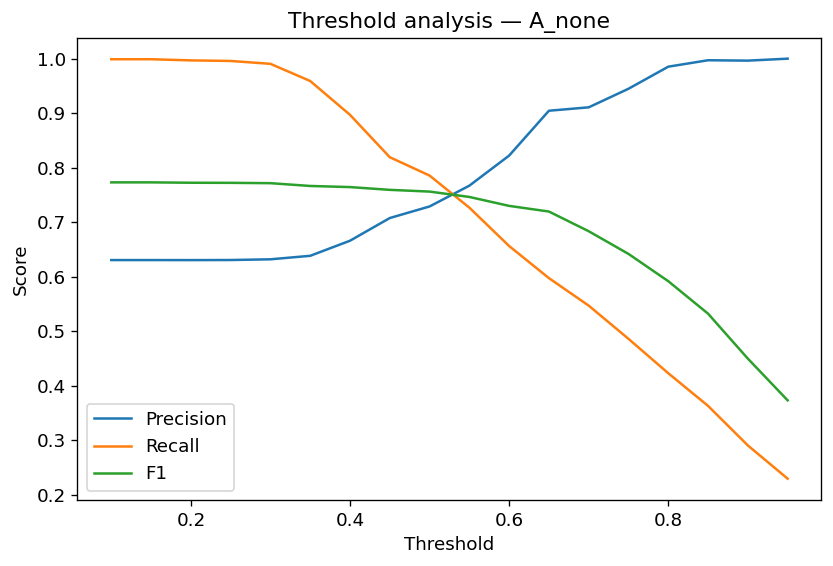

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_results_A_none["threshold"], threshold_results_A_none["precision"], label="Precision")
plt.plot(threshold_results_A_none["threshold"], threshold_results_A_none["recall"],    label="Recall")
plt.plot(threshold_results_A_none["threshold"], threshold_results_A_none["f1"],        label="F1")
plt.title("Threshold analysis — A_none")
plt.xlabel("Threshold"); plt.ylabel("Score"); plt.legend(); plt.show()


## Tuned confusion matrices 

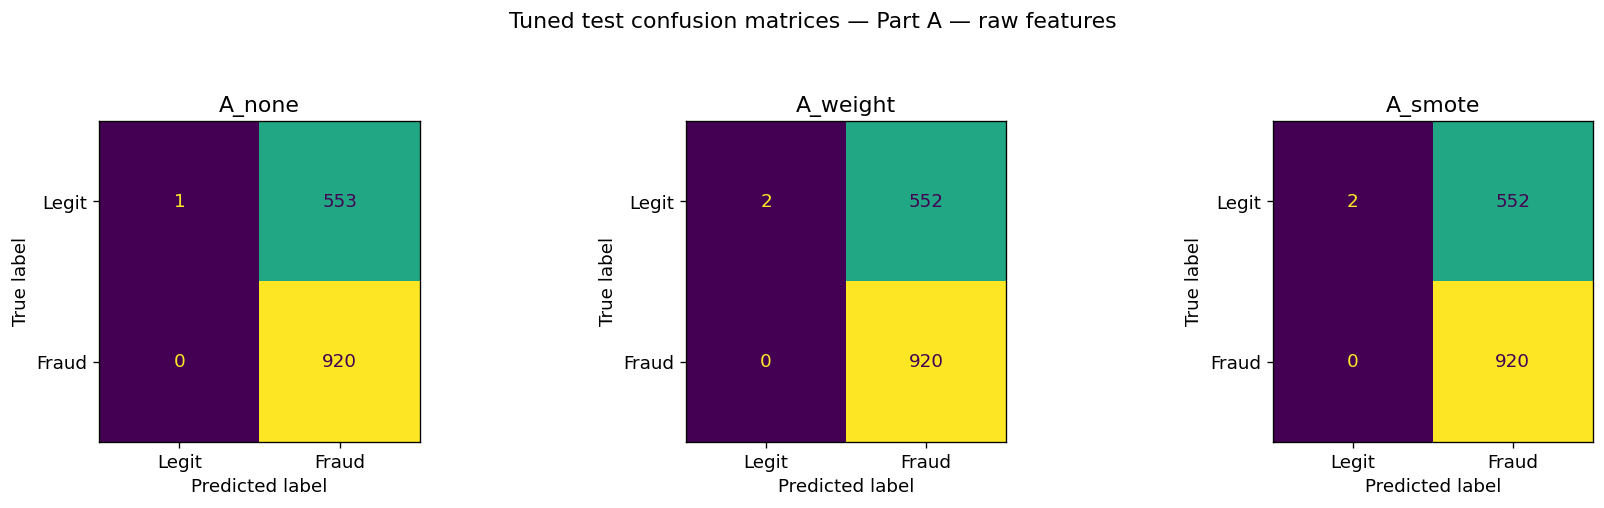

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (cm, title_) in zip(axes, [(tuned_cm_A_none, "A_none"), (tuned_cm_A_weight, "A_weight"), (tuned_cm_A_smote, "A_smote")]):
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit","Fraud"]).plot(
        ax=ax, colorbar=False, values_format="d")
    ax.set_title(title_)
plt.suptitle("Tuned test confusion matrices — Part A — raw features", y=1.05)
plt.tight_layout(); plt.show()


## Threshold analysis 

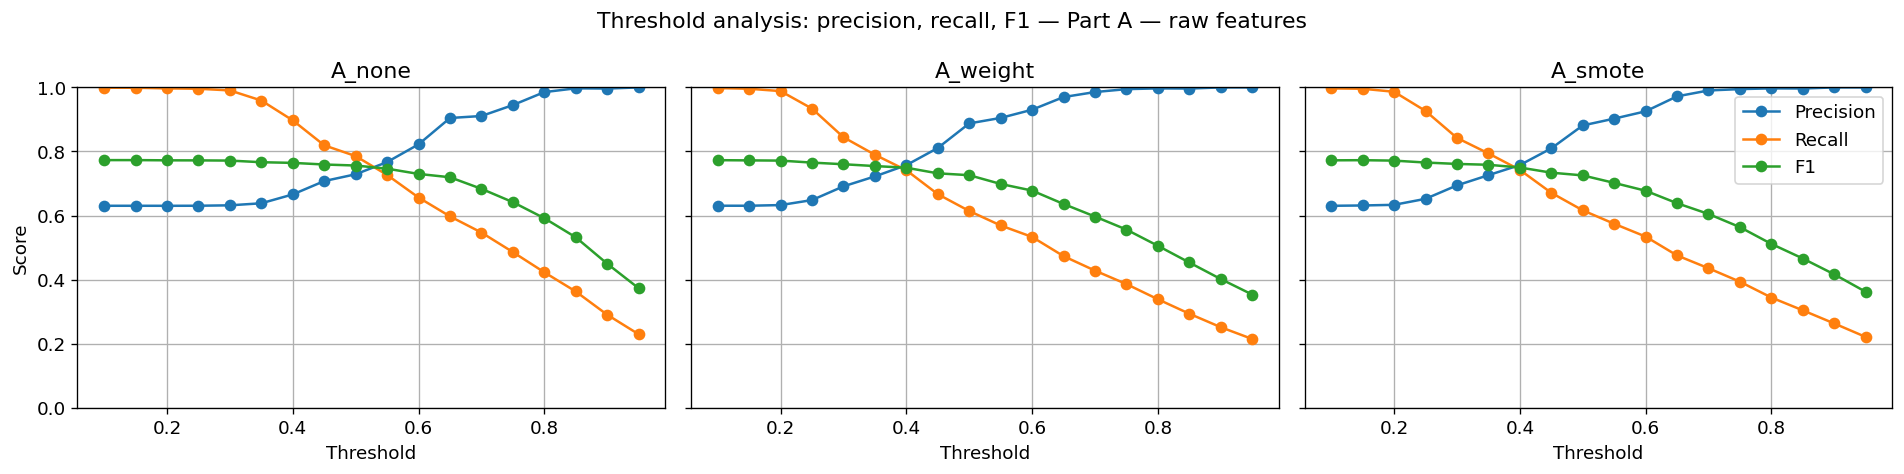

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (df, title_) in zip(axes, [(threshold_results_A_none, "A_none"), (threshold_results_A_weight, "A_weight"), (threshold_results_A_smote, "A_smote")]):
    ax.plot(df["threshold"], df["precision"], marker="o", label="Precision")
    ax.plot(df["threshold"], df["recall"],    marker="o", label="Recall")
    ax.plot(df["threshold"], df["f1"],        marker="o", label="F1")
    ax.set_title(title_); ax.set_xlabel("Threshold"); ax.set_ylim(0, 1); ax.grid(True)
axes[0].set_ylabel("Score"); axes[-1].legend(loc="best")
plt.suptitle("Threshold analysis: precision, recall, F1 — Part A — raw features")
plt.tight_layout(); plt.show()


## Expected cost by threshold 

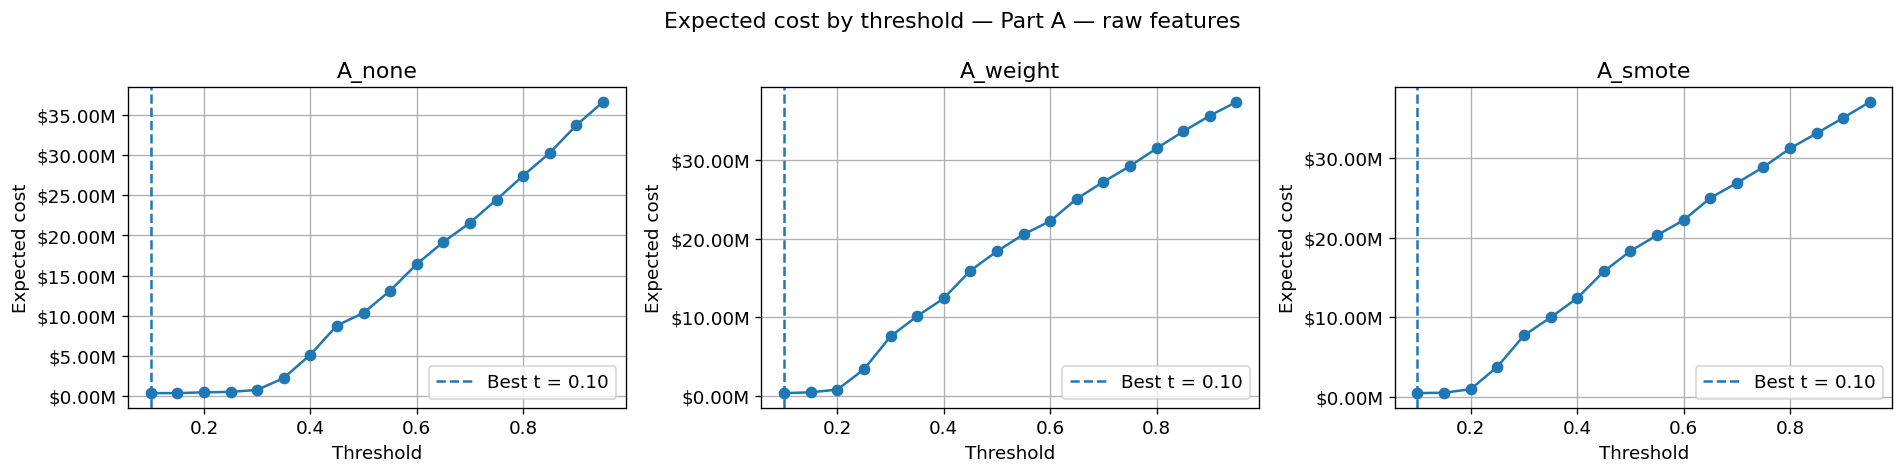

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, (df, title_) in zip(axes, [(cost_df_A_none, "A_none"), (cost_df_A_weight, "A_weight"), (cost_df_A_smote, "A_smote")]):
    df_sorted = df.sort_values("threshold")
    best_row  = df.loc[df["expected_cost"].idxmin()]
    ax.plot(df_sorted["threshold"], df_sorted["expected_cost"], marker="o")
    ax.axvline(best_row["threshold"], linestyle="--",
               label=f"Best t = {best_row['threshold']:.2f}")
    ax.set_title(title_); ax.set_xlabel("Threshold"); ax.set_ylabel("Expected cost")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.2f}M"))
    ax.grid(True); ax.legend()
plt.suptitle("Expected cost by threshold — Part A — raw features")
plt.tight_layout(); plt.show()


## Precision-Recall curves 

In [45]:
from sklearn.metrics import precision_recall_curve
p_0, r_0, _ = precision_recall_curve(X_val_raw_y, model_a_none.predict_proba(X_val_raw)[:, 1])
p_1, r_1, _ = precision_recall_curve(X_val_raw_y, model_a_weight.predict_proba(X_val_raw)[:, 1])
p_2, r_2, _ = precision_recall_curve(X_val_raw_y, model_a_smote.predict_proba(X_val_raw)[:, 1])
plt.figure(figsize=(7, 6))
plt.plot(r_0, p_0, label="A_none")
plt.plot(r_1, p_1, label="A_weight")
plt.plot(r_2, p_2, label="A_smote")
plt.title("Precision-Recall curves — Part A — raw features")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend(); plt.show()

NameError: name 'X_val_raw_y' is not defined

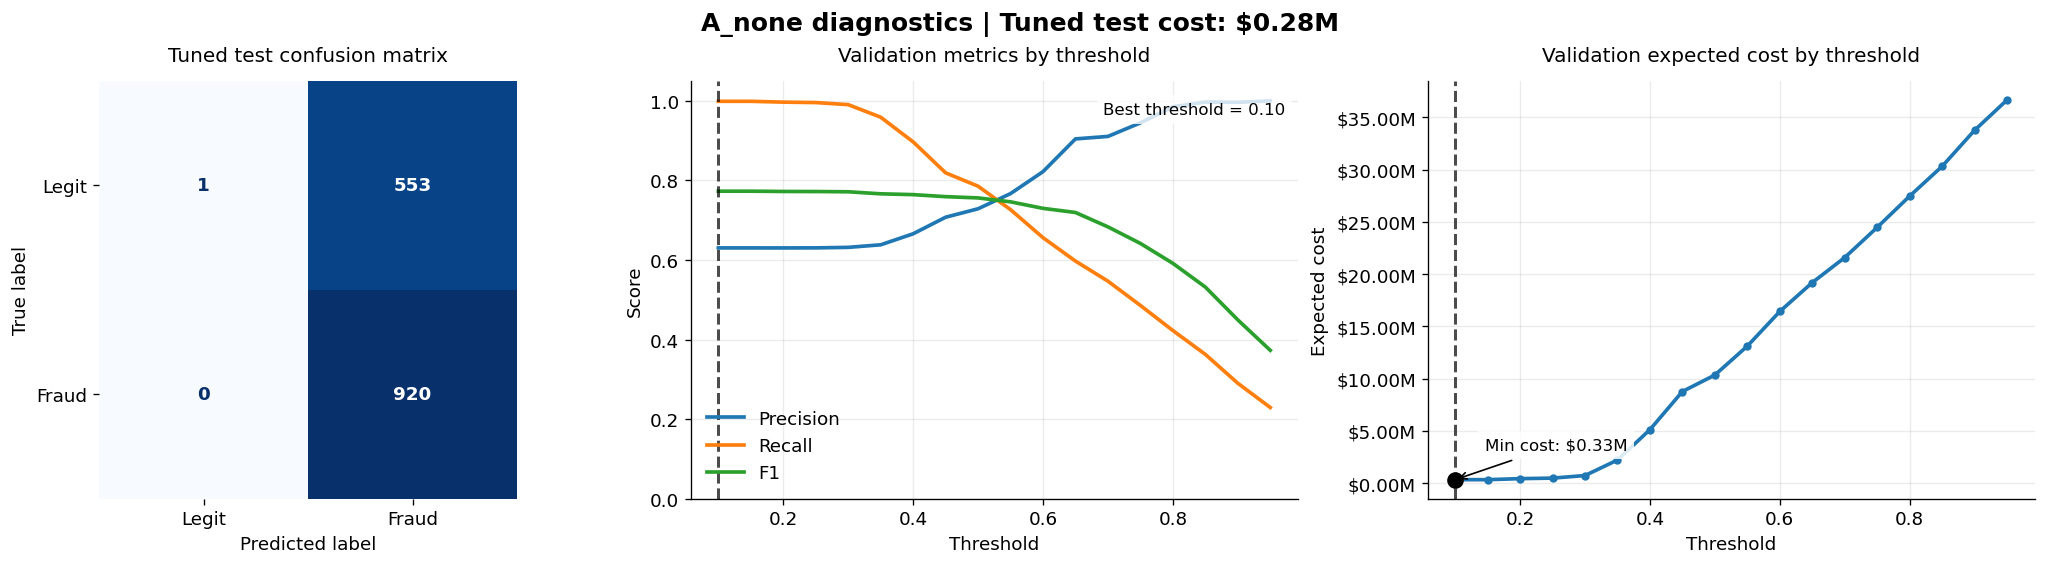

In [46]:
plot_model_diagnostics_pretty(
    cm=tuned_cm_A_none,
    threshold_results=threshold_results_A_none,
    cost_df=cost_df_A_none,
    model_name="A_none",
    save_path=RESULTS_ROOT / "diagnostics_A_none.png",
)


The A_none diagnostics show that cost-based threshold tuning selects a very low threshold of 0.10. At this threshold, the model detects all 920 fraud cases and has no false negatives, which keeps the expected cost low at about $0.28M.

However, the confusion matrix shows that this comes at a major cost: the model predicts almost every transaction as fraud. It correctly identifies only 1 legitimate case and incorrectly flags 553 legitimate cases as fraud. This means the model has very high fraud recall, but almost no ability to identify legitimate transactions.

The threshold plots explain this behavior. As the threshold increases, precision improves, but recall drops quickly. Because false negatives are much more expensive than false positives, the cost curve selects the lowest threshold. Therefore, the cost-tuned A_none model is cost-efficient mathematically, but it is not a balanced classifier.

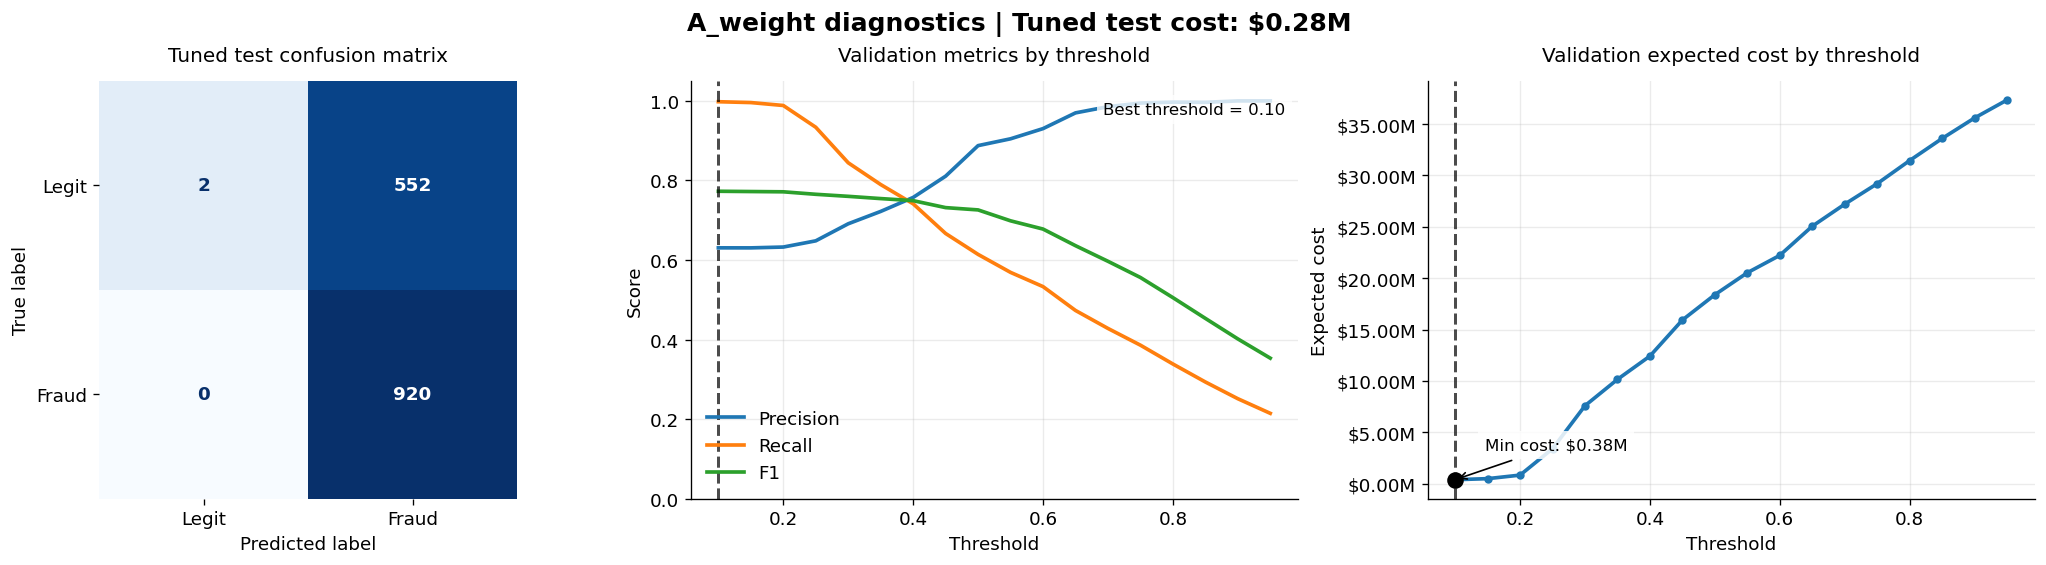

In [47]:
plot_model_diagnostics_pretty(
    cm=tuned_cm_A_weight,
    threshold_results=threshold_results_A_weight,
    cost_df=cost_df_A_weight,
    model_name="A_weight",
    save_path=RESULTS_ROOT / "diagnostics_A_weight.png",
)


The A_weight diagnostics show the same pattern as A_none. Cost-based threshold tuning selects a low threshold of 0.10, which allows the model to detect all 920 fraud cases and avoid false negatives.

However, the model still classifies almost every transaction as fraud. It correctly identifies only 2 legitimate cases and incorrectly flags 552 legitimate cases as fraud. This means that the tuned model has perfect fraud recall, but almost no ability to recognize legitimate transactions.



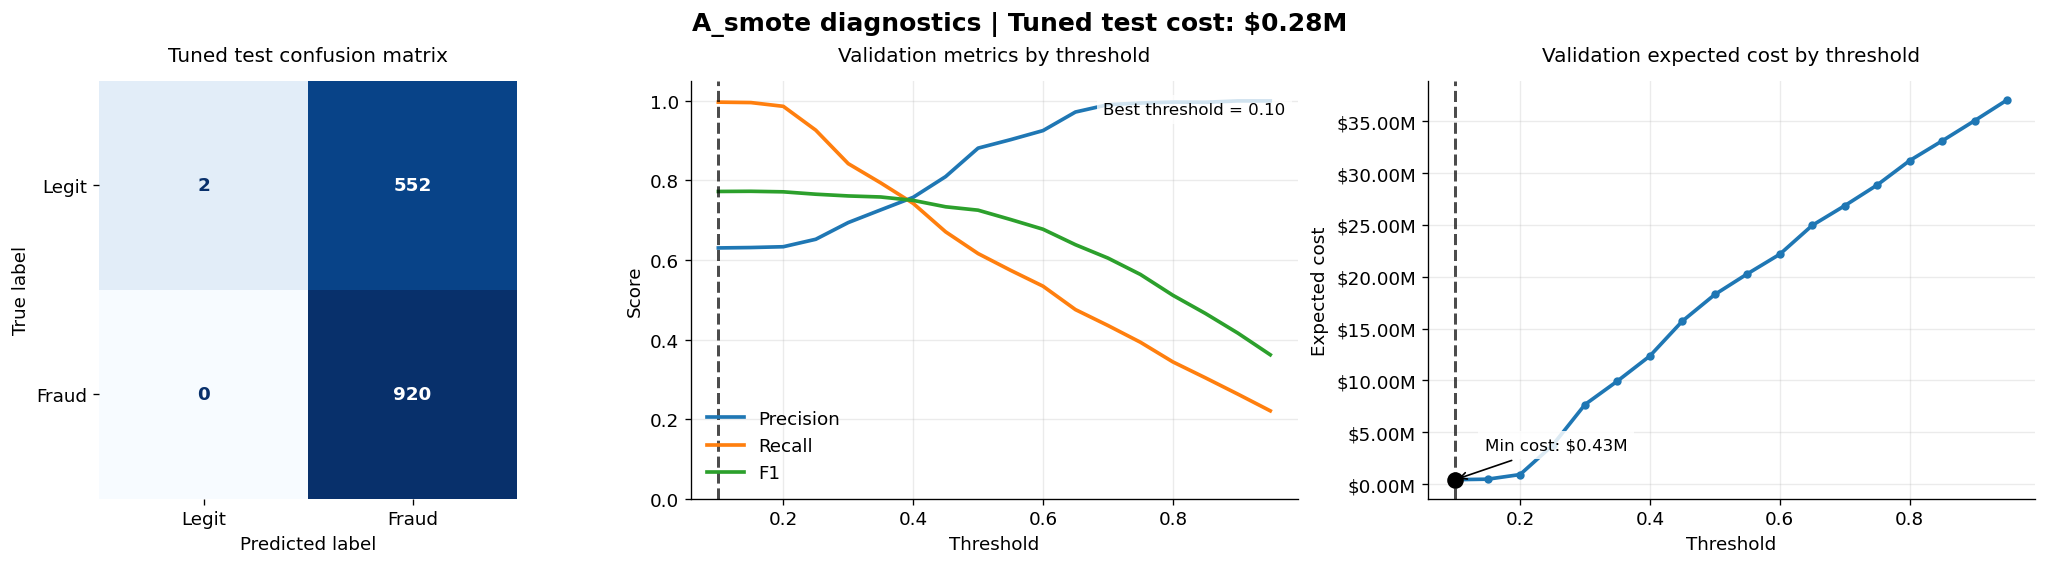

In [48]:
plot_model_diagnostics_pretty(
    cm=tuned_cm_A_smote,
    threshold_results=threshold_results_A_smote,
    cost_df=cost_df_A_smote,
    model_name="A_smote",
    save_path=RESULTS_ROOT / "diagnostics_A_smote.png",
)


The A_weigh and A_smote Logistic Regression variants show almost identical behavior after cost-based threshold tuning. Both models select the lowest tested threshold of 0.10 and classify nearly all observations as fraud. As a result, both detect all 920 fraud cases and have zero false negatives, but they correctly identify only 2 legitimate cases and produce 552 false positives.

This suggests that, for the raw-feature Logistic Regression models on the multimodal subset, the thresholding objective dominates the effect of the imbalance-handling method. Once the threshold is lowered to minimize expected cost, both class weighting and SMOTE lead to the same practical prediction pattern.

## Final choice 


In [50]:
final_part_a_raw_features = comparison_a.sort_values("tuned_expected_cost").copy()
final_part_a_raw_features


,model,val_f1,val_roc_auc,val_pr_auc,test_f1,test_roc_auc,test_pr_auc,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
1,A_weight,0.725917,0.769373,0.881358,0.727742,0.781086,0.885036,0.1,0.625000,1.0,0.769231,276000
2,A_smote,0.725248,0.769680,0.881904,0.730893,0.781971,0.885883,0.1,0.625000,1.0,0.769231,276000
0,A_none,0.756073,0.767932,0.880144,0.754219,0.781173,0.884339,0.1,0.624576,1.0,0.768909,276500


---
## Part B - Engineered features
Adds 5 balance-delta/ratio features. Same engineering as notebook 12 Part B.

In [51]:
train_fe = engineer_features(train_df)
val_fe   = engineer_features(val_df)
test_fe  = engineer_features(test_df)

X_train_fe = train_fe[FE_COLS]
X_val_fe   = val_fe[FE_COLS]
X_test_fe  = test_fe[FE_COLS]

print("Features:", list(FE_COLS))
print("X_train shape:", X_train_fe.shape)


Features: ['tab_step', 'tab_amount', 'tab_oldbalanceOrg', 'tab_newbalanceOrig', 'tab_oldbalanceDest', 'tab_newbalanceDest', 'tab_isFlaggedFraud', 'tab_balance_delta_orig', 'tab_balance_delta_dest', 'tab_amount_ratio_orig', 'tab_amount_ratio_dest', 'tab_orig_balance_zeroed', 'tab_type']
X_train shape: (7182, 13)


In [52]:
preprocessor_fe = build_preprocessor(NUMERIC_FE, CAT_COLS)
preprocessor_fe


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['tab_step', 'tab_amount', 'tab_oldbalanceOrg',
                                  'tab_newbalanceOrig', 'tab_oldbalanceDest',
                                  'tab_newbalanceDest', 'tab_isFlaggedFraud',
                                  'tab_balance_delta_orig',
                                  'tab_balance_delta_dest',
                                  'tab_amount_ratio_orig',
                                  'tab_amount_ratio_dest',
                                  'tab_orig_balance_zeroed']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['tab_type'])])

## 4. LR - B_none

LR without imbalance correction, engineered features.

In [53]:
import joblib

results_dir = RESULTS_ROOT / "B_none"
results_dir.mkdir(parents=True, exist_ok=True)

model_path    = results_dir / "B_none_model.joblib"
FORCE_RETRAIN = False

print("Checking model path:")
print(model_path)
print("Model exists:", model_path.exists())

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved LR — B_none model...")
    model_b_none = joblib.load(model_path)
    print("Model loaded successfully.")
else:
    print("Saved model not found. Training LR — B_none model...")
    preprocessor_fe = build_preprocessor(NUMERIC_FE, CAT_COLS)
    model_b_none = build_logreg_pipeline(preprocessor_fe, imbalance_method="none")
    model_b_none = fit_model(model_b_none, X_train_fe, y_train)
    joblib.dump(model_b_none, model_path)
    print("Training finished and model saved to:", model_path)


Checking model path:
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_logreg\B_none\B_none_model.joblib
Model exists: True
Already trained. Loading saved LR — B_none model...
Model loaded successfully.


In [54]:
val_metrics_B_none,  val_cm_B_none  = evaluate_model(model_b_none, X_val_fe,  y_val,  split_name="validation_B_none")
test_metrics_B_none, test_cm_B_none = evaluate_model(model_b_none, X_test_fe, y_test, split_name="test_B_none")



=== VALIDATION_B_NONE ===
accuracy: 0.682361
precision: 0.732283
recall: 0.782334
f1: 0.756482
roc_auc: 0.776748
pr_auc: 0.887079

Confusion matrix:
[[285 272]
 [207 744]]

Classification report:
              precision    recall  f1-score   support

           0     0.5793    0.5117    0.5434       557
           1     0.7323    0.7823    0.7565       951

    accuracy                         0.6824      1508
   macro avg     0.6558    0.6470    0.6499      1508
weighted avg     0.6758    0.6824    0.6778      1508


=== TEST_B_NONE ===
accuracy: 0.691316
precision: 0.742440
recall: 0.773913
f1: 0.757850
roc_auc: 0.785893
pr_auc: 0.889925

Confusion matrix:
[[307 247]
 [208 712]]

Classification report:
              precision    recall  f1-score   support

           0     0.5961    0.5542    0.5744       554
           1     0.7424    0.7739    0.7578       920

    accuracy                         0.6913      1474
   macro avg     0.6693    0.6640    0.6661      1474
weighted avg 



The B_none Logistic Regression model uses engineered tabular features without imbalance correction. Compared with the raw-feature A_none model, the performance improves only slightly.

On the test set, B_none achieves accuracy of 0.6913, precision of 0.7424, recall of 0.7739, and F1-score of 0.7579 for the fraud class. The confusion matrix shows that the model correctly detects 712 fraud cases and misses 208. It also correctly identifies 307 legitimate cases, while incorrectly flagging 247 legitimate cases as fraud.

Compared with A_none, the engineered features slightly improve legitimate-class detection and reduce false positives. However, fraud recall remains similar, and the overall improvement is small. The macro F1-score is 0.6661, which shows that the model still performs much better on fraud than on legitimate cases.

So engineered features provide a small improvement for Logistic Regression on the multimodal tabular subset, but the model still has limited ability to separate the two classes clearly.

### Threshold tuning for LR B_none

Cost-based threshold tuning on the validation set.

In [55]:
threshold_results_B_none = search_thresholds(model_b_none, X_val_fe, y_val)
print(threshold_results_B_none)


    threshold  precision    recall        f1  predicted_fraud
0        0.10   0.630319  0.996845  0.772301             1504
1        0.15   0.630913  0.995794  0.772431             1501
2        0.20   0.631755  0.995794  0.773061             1499
3        0.25   0.632215  0.990536  0.771815             1490
4        0.30   0.634576  0.984227  0.771641             1475
5        0.35   0.643317  0.946372  0.765957             1399
6        0.40   0.667191  0.891693  0.763276             1271
7        0.45   0.696600  0.840168  0.761678             1147
8        0.50   0.732283  0.782334  0.756482             1016
9        0.55   0.796209  0.706625  0.748747              844
10       0.60   0.877698  0.641430  0.741191              695
11       0.65   0.911433  0.595163  0.720102              621
12       0.70   0.938272  0.559411  0.700922              567
13       0.75   0.969697  0.504732  0.663900              495
14       0.80   0.990762  0.451104  0.619942              433
15      

In [56]:
cost_df_B_none = compute_cost_table(threshold_results_B_none, y_val)
print(cost_df_B_none.head())


   threshold   tp   fp  fn  tn  precision    recall        f1  \
0       0.10  948  556   3   1   0.630319  0.996845  0.772301   
1       0.20  947  552   4   5   0.631755  0.995794  0.773061   
2       0.15  947  554   4   3   0.630913  0.995794  0.772431   
3       0.25  942  548   9   9   0.632215  0.990536  0.771815   
4       0.30  936  539  15  18   0.634576  0.984227  0.771641   

   predicted_fraud  expected_cost  
0             1504         428000  
1             1499         476000  
2             1501         477000  
3             1490         724000  
4             1475        1019500  




Threshold tuning was applied to the B_none Logistic Regression model using the validation set. The lowest expected validation cost is achieved at threshold 0.10.

At this threshold, the model detects 948 fraud cases and misses only 3. However, it also produces 556 false positives and correctly identifies only 1 legitimate case. This means that, after cost-based tuning, the model again becomes very aggressive and predicts almost all observations as fraud.

The expected validation cost at threshold 0.10 is:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 3 × $50,000 + 556 × $500  
Expected cost = $428,000

Although the engineered features slightly improve the default-threshold performance, they do not prevent the cost-based threshold from collapsing toward a fraud-heavy prediction strategy. The cost objective is still dominated by the high penalty for false negatives.

In [57]:
val_cost_B_none      = compute_expected_cost_from_cm(val_cm_B_none)
default_validation_cost = val_cost_B_none["expected_cost"]
best_validation_cost    = cost_df_B_none.iloc[0]["expected_cost"]
cost_reduction          = default_validation_cost - best_validation_cost

print(f"Default validation cost:    ${default_validation_cost:,.0f}")
print(f"Best tuned validation cost: ${best_validation_cost:,.0f}")
print(f"Cost reduction:             ${cost_reduction:,.0f}")


Default validation cost:    $10,486,000
Best tuned validation cost: $428,000
Cost reduction:             $10,058,000


### Cost-tuned test results for B_none Logistic Regression

In [58]:
best_threshold_B_none = float(cost_df_B_none.iloc[0]["threshold"])
best_threshold_B_none


0.1

In [59]:
tuned_metrics_B_none, tuned_cm_B_none = evaluate_with_threshold(
    model_b_none, X_test_fe, y_test, best_threshold_B_none)
cost_summary_B_none = compute_expected_cost_from_cm(tuned_cm_B_none)
print(cost_summary_B_none)



Tuned threshold: 0.1
Precision: 0.625
Recall: 1.0
F1: 0.7692307692307693

Confusion matrix:
[[  2 552]
 [  0 920]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.0036    0.0072       554
           1     0.6250    1.0000    0.7692       920

    accuracy                         0.6255      1474
   macro avg     0.8125    0.5018    0.3882      1474
weighted avg     0.7659    0.6255    0.4828      1474

{'tp': 920, 'fp': 552, 'fn': 0, 'tn': 2, 'expected_cost': 276000}




After cost-based threshold tuning, the selected threshold for the B_none Logistic Regression model was 0.10. At this threshold, the model detects all 920 fraud cases in the test set, so recall reaches 1.0000.

However, the model also becomes extremely aggressive. It correctly identifies only 2 legitimate cases and incorrectly flags 552 legitimate cases as fraud. This means that almost every observation is classified as fraud.

The expected test cost is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 0 × $50,000 + 552 × $500  
Expected cost = $276,000

This is a low expected cost, but the macro F1-score is only 0.3882 because the model performs very poorly on the legitimate class. Therefore, engineered features do not solve the main issue for Logistic Regression under cost-based tuning: the model minimizes missed fraud, but almost completely sacrifices legitimate-class detection.

In [60]:
save_experiment_outputs(
    results_dir=results_dir,
    model=model_b_none,
    val_metrics=val_metrics_B_none,
    test_metrics=test_metrics_B_none,
    val_cm=val_cm_B_none,
    test_cm=test_cm_B_none,
    threshold_results=threshold_results_B_none,
    cost_df=cost_df_B_none,
    tuned_metrics=tuned_metrics_B_none,
    tuned_cm=tuned_cm_B_none,
    prefix="B_none",
)
print("Saved outputs to:", results_dir)


Saved outputs to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_logreg\B_none


In [61]:
saved_files = sorted([p.name for p in results_dir.glob("*")])
saved_files


['B_none_cost_results.csv',
 'B_none_metrics_summary.csv',
 'B_none_model.joblib',
 'B_none_test_confusion_matrix.csv',
 'B_none_test_metrics.json',
 'B_none_threshold_results.csv',
 'B_none_tuned_test_confusion_matrix.csv',
 'B_none_tuned_test_metrics.json',
 'B_none_validation_confusion_matrix.csv',
 'B_none_validation_metrics.json']

## 5. LR - B_weight

LR with class_weight='balanced', engineered features.

In [62]:
import joblib

results_dir = RESULTS_ROOT / "B_weight"
results_dir.mkdir(parents=True, exist_ok=True)

model_path    = results_dir / "B_weight_model.joblib"
FORCE_RETRAIN = False

print("Checking model path:")
print(model_path)
print("Model exists:", model_path.exists())

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved LR — B_weight model...")
    model_b_weight = joblib.load(model_path)
    print("Model loaded successfully.")
else:
    print("Saved model not found. Training LR — B_weight model...")
    preprocessor_fe = build_preprocessor(NUMERIC_FE, CAT_COLS)
    model_b_weight = build_logreg_pipeline(preprocessor_fe, imbalance_method="class_weight")
    model_b_weight = fit_model(model_b_weight, X_train_fe, y_train)
    joblib.dump(model_b_weight, model_path)
    print("Training finished and model saved to:", model_path)


Checking model path:
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_logreg\B_weight\B_weight_model.joblib
Model exists: True
Already trained. Loading saved LR — B_weight model...
Model loaded successfully.


In [63]:
val_metrics_B_weight,  val_cm_B_weight  = evaluate_model(model_b_weight, X_val_fe,  y_val,  split_name="validation_B_weight")
test_metrics_B_weight, test_cm_B_weight = evaluate_model(model_b_weight, X_test_fe, y_test, split_name="test_B_weight")



=== VALIDATION_B_WEIGHT ===
accuracy: 0.713528
precision: 0.906103
recall: 0.608833
f1: 0.728302
roc_auc: 0.777800
pr_auc: 0.888028

Confusion matrix:
[[497  60]
 [372 579]]

Classification report:
              precision    recall  f1-score   support

           0     0.5719    0.8923    0.6971       557
           1     0.9061    0.6088    0.7283       951

    accuracy                         0.7135      1508
   macro avg     0.7390    0.7506    0.7127      1508
weighted avg     0.7827    0.7135    0.7168      1508


=== TEST_B_WEIGHT ===
accuracy: 0.723881
precision: 0.917073
recall: 0.613043
f1: 0.734853
roc_auc: 0.786338
pr_auc: 0.890747

Confusion matrix:
[[503  51]
 [356 564]]

Classification report:
              precision    recall  f1-score   support

           0     0.5856    0.9079    0.7120       554
           1     0.9171    0.6130    0.7349       920

    accuracy                         0.7239      1474
   macro avg     0.7513    0.7605    0.7234      1474
weighted 

The B_weight Logistic Regression model achieved a fraud-class F1-score of 0.7349 on the test set, with high precision of 0.9171 but low recall of 0.6130. It produced only 51 false positives and correctly identified 503 legitimate cases, but it missed 356 fraud cases. This shows that class weighting with engineered features made the model more conservative: it improved legitimate-class detection but reduced fraud sensitivity.

### Threshold tuning for LR B_weight

Cost-based threshold tuning on the validation set.

In [64]:
threshold_results_B_weight = search_thresholds(model_b_weight, X_val_fe, y_val)
print(threshold_results_B_weight)


    threshold  precision    recall        f1  predicted_fraud
0        0.10   0.630667  0.994742  0.771930             1500
1        0.15   0.633244  0.989485  0.772261             1486
2        0.20   0.635482  0.964248  0.766082             1443
3        0.25   0.656627  0.916930  0.765248             1328
4        0.30   0.685811  0.853838  0.760656             1184
5        0.35   0.722599  0.783386  0.751766             1031
6        0.40   0.783410  0.715037  0.747664              868
7        0.45   0.858127  0.655100  0.742993              726
8        0.50   0.906103  0.608833  0.728302              639
9        0.55   0.931973  0.576236  0.712151              588
10       0.60   0.951852  0.540484  0.689470              540
11       0.65   0.975207  0.496320  0.657840              484
12       0.70   0.990991  0.462671  0.630824              444
13       0.75   0.990099  0.420610  0.590406              404
14       0.80   0.994638  0.390116  0.560423              373
15      

In [65]:
cost_df_B_weight = compute_cost_table(threshold_results_B_weight, y_val)
print(cost_df_B_weight.head())


   threshold   tp   fp   fn   tn  precision    recall        f1  \
0       0.10  946  554    5    3   0.630667  0.994742  0.771930   
1       0.15  941  545   10   12   0.633244  0.989485  0.772261   
2       0.20  917  526   34   31   0.635482  0.964248  0.766082   
3       0.25  872  456   79  101   0.656627  0.916930  0.765248   
4       0.30  812  372  139  185   0.685811  0.853838  0.760656   

   predicted_fraud  expected_cost  
0             1500         527000  
1             1486         772500  
2             1443        1963000  
3             1328        4178000  
4             1184        7136000  




Threshold tuning was applied to the B_weight Logistic Regression model using the validation set. The lowest expected validation cost is achieved at threshold 0.10.

At this threshold, the model detects 946 fraud cases and misses only 5. However, it also produces 554 false positives and correctly identifies only 3 legitimate cases. This means that cost-based tuning again makes the model highly aggressive.

The expected validation cost at threshold 0.10 is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 5 × $50,000 + 554 × $500  
Expected cost = $250,000 + $277,000  
Expected cost = $527,000



In [66]:
val_cost_B_weight      = compute_expected_cost_from_cm(val_cm_B_weight)
default_validation_cost = val_cost_B_weight["expected_cost"]
best_validation_cost    = cost_df_B_weight.iloc[0]["expected_cost"]
cost_reduction          = default_validation_cost - best_validation_cost

print(f"Default validation cost:    ${default_validation_cost:,.0f}")
print(f"Best tuned validation cost: ${best_validation_cost:,.0f}")
print(f"Cost reduction:             ${cost_reduction:,.0f}")


Default validation cost:    $18,630,000
Best tuned validation cost: $527,000
Cost reduction:             $18,103,000


### Tuned threshold results for LR B_weight

In [67]:
best_threshold_B_weight = float(cost_df_B_weight.iloc[0]["threshold"])
best_threshold_B_weight


0.1

In [68]:
tuned_metrics_B_weight, tuned_cm_B_weight = evaluate_with_threshold(
    model_b_weight, X_test_fe, y_test, best_threshold_B_weight)
cost_summary_B_weight = compute_expected_cost_from_cm(tuned_cm_B_weight)
print(cost_summary_B_weight)



Tuned threshold: 0.1
Precision: 0.625938566552901
Recall: 0.9967391304347826
F1: 0.7689727463312369

Confusion matrix:
[[  6 548]
 [  3 917]]

Classification report:
              precision    recall  f1-score   support

           0     0.6667    0.0108    0.0213       554
           1     0.6259    0.9967    0.7690       920

    accuracy                         0.6262      1474
   macro avg     0.6463    0.5038    0.3951      1474
weighted avg     0.6412    0.6262    0.4880      1474

{'tp': 917, 'fp': 548, 'fn': 3, 'tn': 6, 'expected_cost': 424000}




After cost-based threshold tuning, the selected threshold for the B_weight Logistic Regression model was 0.10. At this threshold, the model becomes much more sensitive to fraud.

On the test set, the model detects 917 out of 920 fraud cases and misses only 3. This gives a very high recall of 0.9967. However, it also incorrectly flags 548 legitimate cases as fraud and correctly identifies only 6 legitimate cases.

The expected test cost is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 3 × $50,000 + 548 × $500  
Expected cost = $150,000 + $274,000  
Expected cost = $424,000



In [69]:
save_experiment_outputs(
    results_dir=results_dir,
    model=model_b_weight,
    val_metrics=val_metrics_B_weight,
    test_metrics=test_metrics_B_weight,
    val_cm=val_cm_B_weight,
    test_cm=test_cm_B_weight,
    threshold_results=threshold_results_B_weight,
    cost_df=cost_df_B_weight,
    tuned_metrics=tuned_metrics_B_weight,
    tuned_cm=tuned_cm_B_weight,
    prefix="B_weight",
)
print("Saved outputs to:", results_dir)


Saved outputs to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_logreg\B_weight


In [70]:
saved_files = sorted([p.name for p in results_dir.glob("*")])
saved_files


['B_weight_cost_results.csv',
 'B_weight_metrics_summary.csv',
 'B_weight_model.joblib',
 'B_weight_test_confusion_matrix.csv',
 'B_weight_test_metrics.json',
 'B_weight_threshold_results.csv',
 'B_weight_tuned_test_confusion_matrix.csv',
 'B_weight_tuned_test_metrics.json',
 'B_weight_validation_confusion_matrix.csv',
 'B_weight_validation_metrics.json']

## 6. LR - B_smote

LR with SMOTE, engineered features.

In [71]:
import joblib

results_dir = RESULTS_ROOT / "B_smote"
results_dir.mkdir(parents=True, exist_ok=True)

model_path    = results_dir / "B_smote_model.joblib"
FORCE_RETRAIN = False

print("Checking model path:")
print(model_path)
print("Model exists:", model_path.exists())

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved LR — B_smote model...")
    model_b_smote = joblib.load(model_path)
    print("Model loaded successfully.")
else:
    print("Saved model not found. Training LR — B_smote model...")
    preprocessor_fe = build_preprocessor(NUMERIC_FE, CAT_COLS)
    model_b_smote = build_logreg_pipeline(preprocessor_fe, imbalance_method="smote")
    model_b_smote = fit_model(model_b_smote, X_train_fe, y_train)
    joblib.dump(model_b_smote, model_path)
    print("Training finished and model saved to:", model_path)


Checking model path:
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_logreg\B_smote\B_smote_model.joblib
Model exists: True
Already trained. Loading saved LR — B_smote model...
Model loaded successfully.


In [72]:
val_metrics_B_smote,  val_cm_B_smote  = evaluate_model(model_b_smote, X_val_fe,  y_val,  split_name="validation_B_smote")
test_metrics_B_smote, test_cm_B_smote = evaluate_model(model_b_smote, X_test_fe, y_test, split_name="test_B_smote")



=== VALIDATION_B_SMOTE ===
accuracy: 0.715517
precision: 0.904025
recall: 0.614090
f1: 0.731371
roc_auc: 0.777520
pr_auc: 0.887966

Confusion matrix:
[[495  62]
 [367 584]]

Classification report:
              precision    recall  f1-score   support

           0     0.5742    0.8887    0.6977       557
           1     0.9040    0.6141    0.7314       951

    accuracy                         0.7155      1508
   macro avg     0.7391    0.7514    0.7145      1508
weighted avg     0.7822    0.7155    0.7189      1508


=== TEST_B_SMOTE ===
accuracy: 0.725916
precision: 0.917476
recall: 0.616304
f1: 0.737321
roc_auc: 0.787100
pr_auc: 0.891232

Confusion matrix:
[[503  51]
 [353 567]]

Classification report:
              precision    recall  f1-score   support

           0     0.5876    0.9079    0.7135       554
           1     0.9175    0.6163    0.7373       920

    accuracy                         0.7259      1474
   macro avg     0.7525    0.7621    0.7254      1474
weighted av

The B_SMOTE Logistic Regression model achieved a fraud-class F1-score of 0.7373 on the test set, with high precision of 0.9175 but lower recall of 0.6163. It correctly identified 503 legitimate cases and produced only 51 false positives, but it missed 353 fraud cases. This shows that SMOTE with engineered features makes the model conservative and improves legitimate-class detection, but it still fails to detect a large share of fraud cases.

### Threshold tuning for LR B_smote

Cost-based threshold tuning on the validation set.

In [73]:
threshold_results_B_smote = search_thresholds(model_b_smote, X_val_fe, y_val)
print(threshold_results_B_smote)


    threshold  precision    recall        f1  predicted_fraud
0        0.10   0.631755  0.995794  0.773061             1499
1        0.15   0.633850  0.988433  0.772391             1483
2        0.20   0.636047  0.961094  0.765494             1437
3        0.25   0.659074  0.912723  0.765432             1317
4        0.30   0.686224  0.848580  0.758815             1176
5        0.35   0.726214  0.786540  0.755174             1030
6        0.40   0.775626  0.716088  0.744669              878
7        0.45   0.850136  0.656151  0.740653              734
8        0.50   0.904025  0.614090  0.731371              646
9        0.55   0.931208  0.583596  0.717518              596
10       0.60   0.952118  0.543638  0.692102              543
11       0.65   0.975258  0.497371  0.658774              485
12       0.70   0.986547  0.462671  0.629921              446
13       0.75   0.992701  0.429022  0.599119              411
14       0.80   0.994681  0.393270  0.563677              376
15      

In [74]:
cost_df_B_smote = compute_cost_table(threshold_results_B_smote, y_val)
print(cost_df_B_smote.head())


   threshold   tp   fp   fn   tn  precision    recall        f1  \
0       0.10  947  552    4    5   0.631755  0.995794  0.773061   
1       0.15  940  543   11   14   0.633850  0.988433  0.772391   
2       0.20  914  523   37   34   0.636047  0.961094  0.765494   
3       0.25  868  449   83  108   0.659074  0.912723  0.765432   
4       0.30  807  369  144  188   0.686224  0.848580  0.758815   

   predicted_fraud  expected_cost  
0             1499         476000  
1             1483         821500  
2             1437        2111500  
3             1317        4374500  
4             1176        7384500  




Threshold tuning was applied to the B_SMOTE Logistic Regression model using the validation set. The lowest expected validation cost is reached at threshold 0.10.

At this threshold, the model detects 947 fraud cases and misses only 4. However, it also produces 552 false positives and correctly identifies only 5 legitimate cases. This means that cost-based tuning again makes the model highly aggressive.

The expected validation cost at threshold 0.10 is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 4 × $50,000 + 552 × $500  
Expected cost = $200,000 + $276,000  
Expected cost = $476,000



In [75]:
val_cost_B_smote      = compute_expected_cost_from_cm(val_cm_B_smote)
default_validation_cost = val_cost_B_smote["expected_cost"]
best_validation_cost    = cost_df_B_smote.iloc[0]["expected_cost"]
cost_reduction          = default_validation_cost - best_validation_cost

print(f"Default validation cost:    ${default_validation_cost:,.0f}")
print(f"Best tuned validation cost: ${best_validation_cost:,.0f}")
print(f"Cost reduction:             ${cost_reduction:,.0f}")


Default validation cost:    $18,381,000
Best tuned validation cost: $476,000
Cost reduction:             $17,905,000


### Tuned threshold results for LR B_smote

In [76]:
best_threshold_B_smote = float(cost_df_B_smote.iloc[0]["threshold"])
best_threshold_B_smote


0.1

In [85]:
tuned_metrics_B_smote, tuned_cm_B_smote = evaluate_with_threshold(
    model_b_smote, X_test_fe, y_test, best_threshold_B_smote)
cost_summary_B_smote = compute_expected_cost_from_cm(tuned_cm_B_smote)
print(cost_summary_B_smote)



Tuned threshold: 0.1
Precision: 0.6267942583732058
Recall: 0.9967391304347826
F1: 0.7696181284095678

Confusion matrix:
[[  8 546]
 [  3 917]]

Classification report:
              precision    recall  f1-score   support

           0     0.7273    0.0144    0.0283       554
           1     0.6268    0.9967    0.7696       920

    accuracy                         0.6275      1474
   macro avg     0.6770    0.5056    0.3990      1474
weighted avg     0.6646    0.6275    0.4910      1474

{'tp': 917, 'fp': 546, 'fn': 3, 'tn': 8, 'expected_cost': 423000}




After cost-based threshold tuning, the selected threshold for the B_SMOTE Logistic Regression model was 0.10. At this threshold, the model detects 917 out of 920 fraud cases and misses only 3. This gives very high recall of 0.9967.

However, the model also produces 546 false positives and correctly identifies only 8 legitimate cases. This means that the model still predicts fraud for almost all observations. Although the fraud-class F1-score is 0.7696, the macro F1-score is only 0.3990 because legitimate-class performance is very weak.

The expected test cost is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 3 × $50,000 + 546 × $500  
Expected cost = $150,000 + $273,000  
Expected cost = $423,000

Overall, B_SMOTE achieves the lowest cost among the engineered-feature Logistic Regression variants, but it does so by using a highly aggressive threshold. It reduces missed fraud cases, but it still fails to separate legitimate transactions well.

In [86]:
save_experiment_outputs(
    results_dir=results_dir,
    model=model_b_smote,
    val_metrics=val_metrics_B_smote,
    test_metrics=test_metrics_B_smote,
    val_cm=val_cm_B_smote,
    test_cm=test_cm_B_smote,
    threshold_results=threshold_results_B_smote,
    cost_df=cost_df_B_smote,
    tuned_metrics=tuned_metrics_B_smote,
    tuned_cm=tuned_cm_B_smote,
    prefix="B_smote",
)
print("Saved outputs to:", results_dir)


Saved outputs to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_logreg\B_smote


In [87]:
saved_files = sorted([p.name for p in results_dir.glob("*")])
saved_files


['B_smote_cost_results.csv',
 'B_smote_metrics_summary.csv',
 'B_smote_model.joblib',
 'B_smote_test_confusion_matrix.csv',
 'B_smote_test_metrics.json',
 'B_smote_threshold_results.csv',
 'B_smote_tuned_test_confusion_matrix.csv',
 'B_smote_tuned_test_metrics.json',
 'B_smote_validation_confusion_matrix.csv',
 'B_smote_validation_metrics.json']

## Comparison - Part B - engineered features

In [88]:
import pandas as pd

comparison_b = pd.DataFrame([
    {
        "model": "B_none",
        "val_f1": val_metrics_B_none["f1"],
        "val_roc_auc": val_metrics_B_none["roc_auc"],
        "val_pr_auc": val_metrics_B_none["pr_auc"],
        "test_f1": test_metrics_B_none["f1"],
        "test_roc_auc": test_metrics_B_none["roc_auc"],
        "test_pr_auc": test_metrics_B_none["pr_auc"],
        "best_threshold": best_threshold_B_none,
        "tuned_test_precision": tuned_metrics_B_none["precision"],
        "tuned_test_recall": tuned_metrics_B_none["recall"],
        "tuned_test_f1": tuned_metrics_B_none["f1"],
        "tuned_expected_cost": cost_summary_B_none["expected_cost"],
    },
    {
        "model": "B_weight",
        "val_f1": val_metrics_B_weight["f1"],
        "val_roc_auc": val_metrics_B_weight["roc_auc"],
        "val_pr_auc": val_metrics_B_weight["pr_auc"],
        "test_f1": test_metrics_B_weight["f1"],
        "test_roc_auc": test_metrics_B_weight["roc_auc"],
        "test_pr_auc": test_metrics_B_weight["pr_auc"],
        "best_threshold": best_threshold_B_weight,
        "tuned_test_precision": tuned_metrics_B_weight["precision"],
        "tuned_test_recall": tuned_metrics_B_weight["recall"],
        "tuned_test_f1": tuned_metrics_B_weight["f1"],
        "tuned_expected_cost": cost_summary_B_weight["expected_cost"],
    },
    {
        "model": "B_smote",
        "val_f1": val_metrics_B_smote["f1"],
        "val_roc_auc": val_metrics_B_smote["roc_auc"],
        "val_pr_auc": val_metrics_B_smote["pr_auc"],
        "test_f1": test_metrics_B_smote["f1"],
        "test_roc_auc": test_metrics_B_smote["roc_auc"],
        "test_pr_auc": test_metrics_B_smote["pr_auc"],
        "best_threshold": best_threshold_B_smote,
        "tuned_test_precision": tuned_metrics_B_smote["precision"],
        "tuned_test_recall": tuned_metrics_B_smote["recall"],
        "tuned_test_f1": tuned_metrics_B_smote["f1"],
        "tuned_expected_cost": cost_summary_B_smote["expected_cost"],
    },
])

comparison_b


,model,val_f1,val_roc_auc,val_pr_auc,test_f1,test_roc_auc,test_pr_auc,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
0,B_none,0.756482,0.776748,0.887079,0.757850,0.785893,0.889925,0.1,0.625000,1.000000,0.769231,276000
1,B_weight,0.728302,0.777800,0.888028,0.734853,0.786338,0.890747,0.1,0.625939,0.996739,0.768973,424000
2,B_smote,0.731371,0.777520,0.887966,0.737321,0.787100,0.891232,0.1,0.626794,0.996739,0.769618,423000


In [89]:
comparison_b.sort_values("tuned_expected_cost")[
    ["model","best_threshold","tuned_test_precision",
     "tuned_test_recall","tuned_test_f1","tuned_expected_cost"]
]


,model,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
0,B_none,0.1,0.625000,1.000000,0.769231,276000
2,B_smote,0.1,0.626794,0.996739,0.769618,423000
1,B_weight,0.1,0.625939,0.996739,0.768973,424000


## Comparison bar chart 

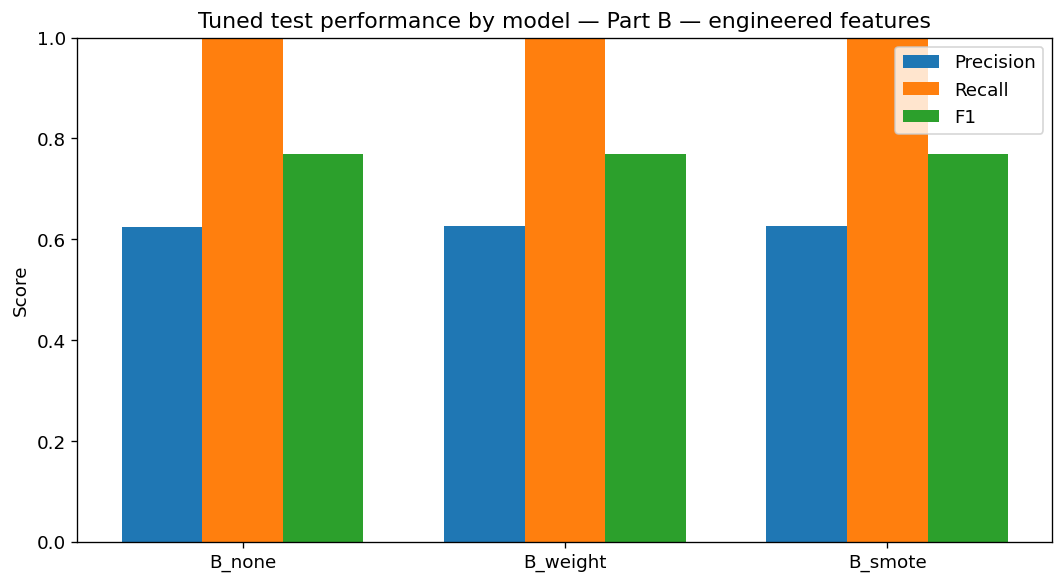

In [90]:
import numpy as np, matplotlib.pyplot as plt
metrics_plot  = ["tuned_test_precision","tuned_test_recall","tuned_test_f1"]
metric_labels = ["Precision","Recall","F1"]
x = np.arange(len(comparison_b["model"])); width = 0.25
plt.figure(figsize=(9, 5))
for i, metric in enumerate(metrics_plot):
    plt.bar(x + i*width, comparison_b[metric], width, label=metric_labels[i])
plt.xticks(x + width, comparison_b["model"])
plt.ylabel("Score")
plt.title("Tuned test performance by model — Part B — engineered features")
plt.legend(); plt.ylim(0, 1); plt.tight_layout(); plt.show()


## Expected cost comparison 

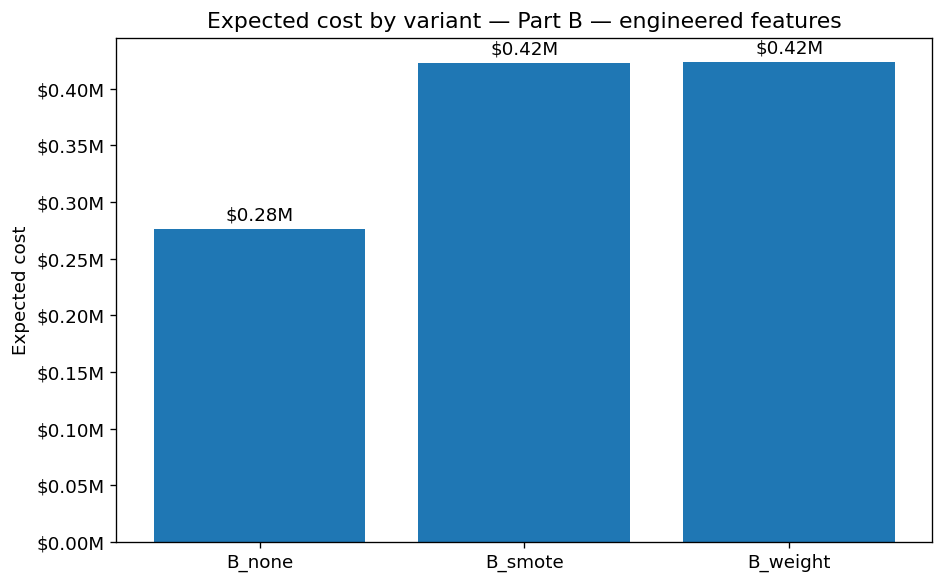

In [91]:
from matplotlib.ticker import FuncFormatter
cost_plot_df = comparison_b.sort_values("tuned_expected_cost")
plt.figure(figsize=(8, 5))
bars = plt.bar(cost_plot_df["model"], cost_plot_df["tuned_expected_cost"])
plt.title("Expected cost by variant — Part B — engineered features")
plt.ylabel("Expected cost")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.2f}M"))
plt.bar_label(bars,
    labels=[f"${v/1_000_000:.2f}M" for v in cost_plot_df["tuned_expected_cost"]],
    padding=3)
plt.tight_layout(); plt.show()


## Threshold performance plot 

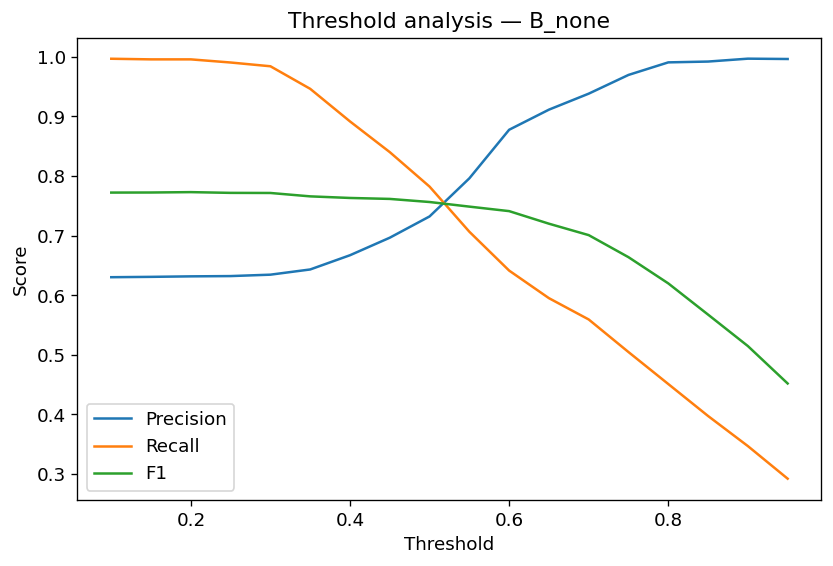

In [92]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_results_B_none["threshold"], threshold_results_B_none["precision"], label="Precision")
plt.plot(threshold_results_B_none["threshold"], threshold_results_B_none["recall"],    label="Recall")
plt.plot(threshold_results_B_none["threshold"], threshold_results_B_none["f1"],        label="F1")
plt.title("Threshold analysis — B_none")
plt.xlabel("Threshold"); plt.ylabel("Score"); plt.legend(); plt.show()


## Tuned confusion matrices 

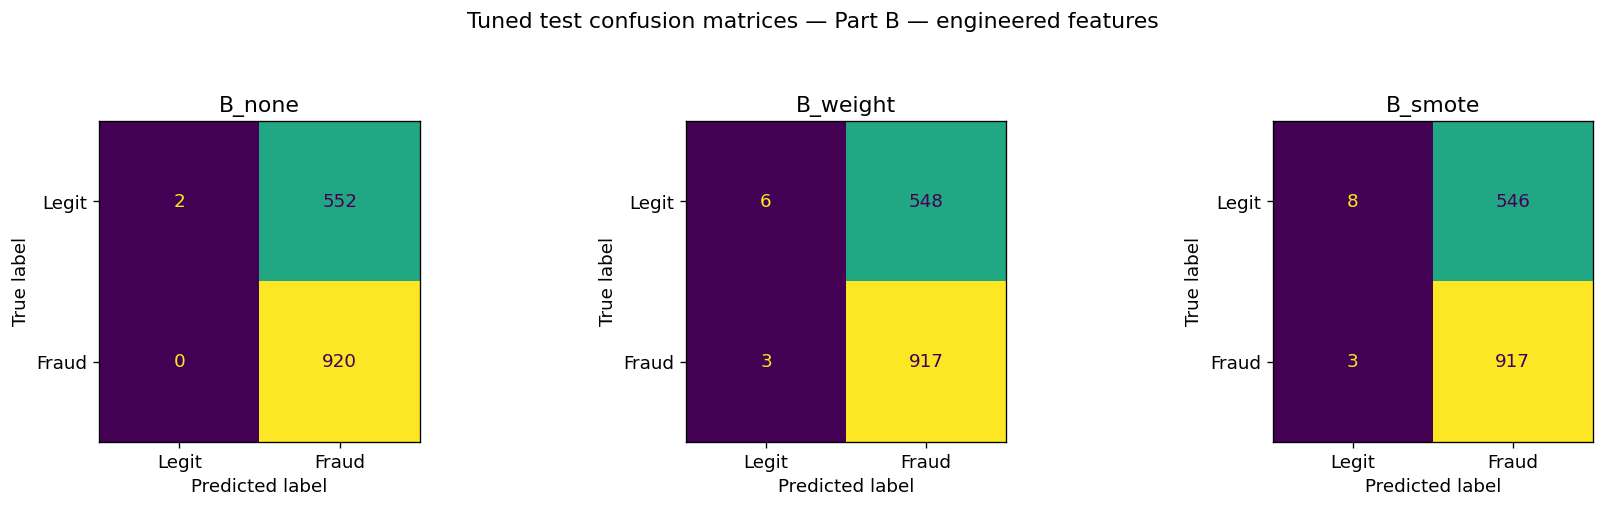

In [93]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (cm, title_) in zip(axes, [(tuned_cm_B_none, "B_none"), (tuned_cm_B_weight, "B_weight"), (tuned_cm_B_smote, "B_smote")]):
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit","Fraud"]).plot(
        ax=ax, colorbar=False, values_format="d")
    ax.set_title(title_)
plt.suptitle("Tuned test confusion matrices — Part B — engineered features", y=1.05)
plt.tight_layout(); plt.show()


## Threshold analysis 

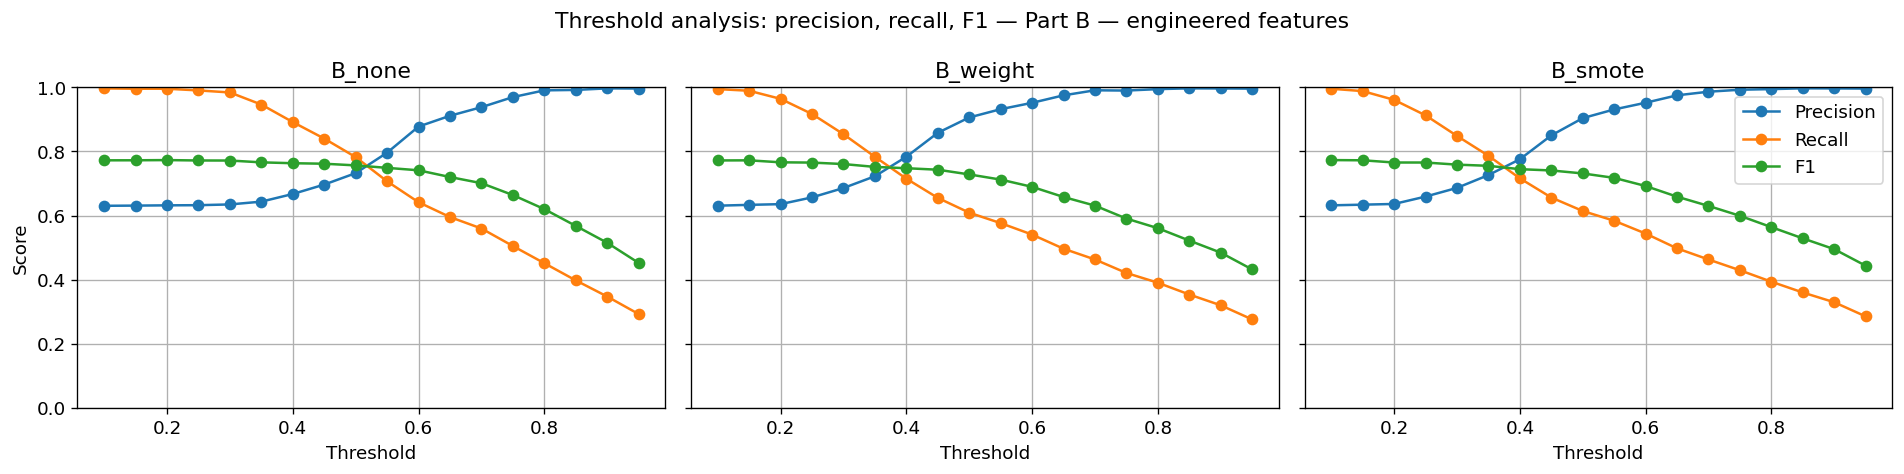

In [94]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (df, title_) in zip(axes, [(threshold_results_B_none, "B_none"), (threshold_results_B_weight, "B_weight"), (threshold_results_B_smote, "B_smote")]):
    ax.plot(df["threshold"], df["precision"], marker="o", label="Precision")
    ax.plot(df["threshold"], df["recall"],    marker="o", label="Recall")
    ax.plot(df["threshold"], df["f1"],        marker="o", label="F1")
    ax.set_title(title_); ax.set_xlabel("Threshold"); ax.set_ylim(0, 1); ax.grid(True)
axes[0].set_ylabel("Score"); axes[-1].legend(loc="best")
plt.suptitle("Threshold analysis: precision, recall, F1 — Part B — engineered features")
plt.tight_layout(); plt.show()


## Expected cost by threshold 

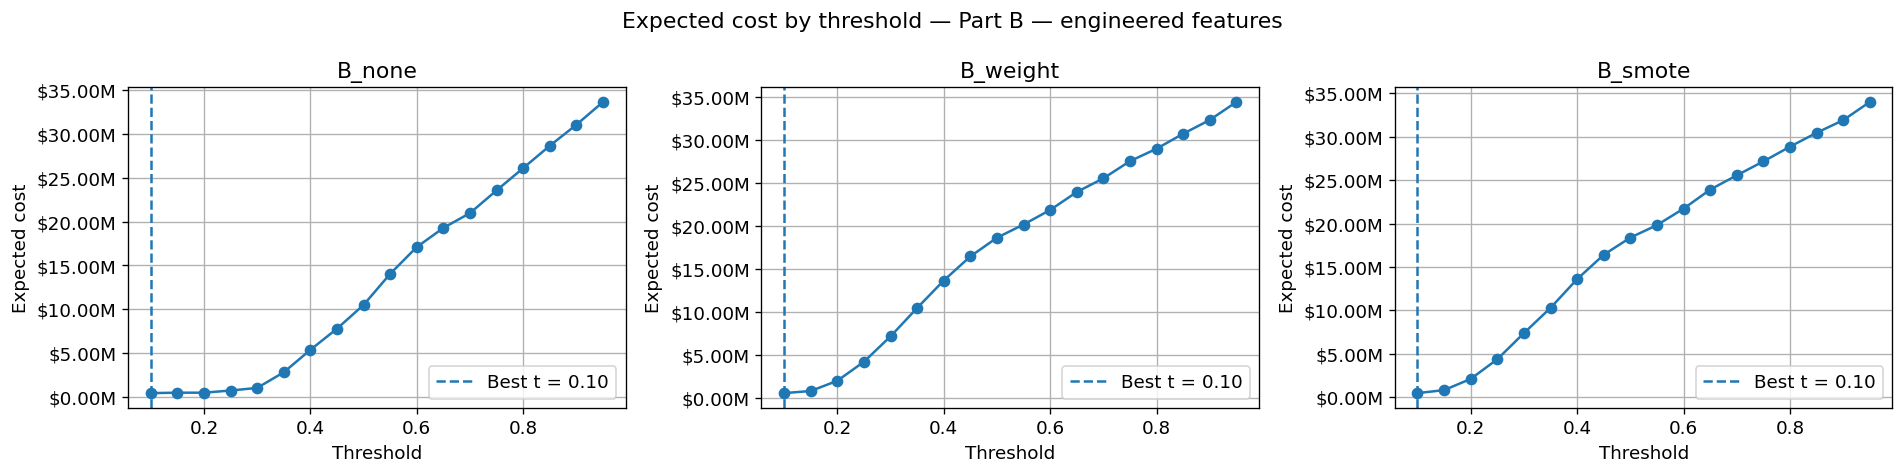

In [95]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, (df, title_) in zip(axes, [(cost_df_B_none, "B_none"), (cost_df_B_weight, "B_weight"), (cost_df_B_smote, "B_smote")]):
    df_sorted = df.sort_values("threshold")
    best_row  = df.loc[df["expected_cost"].idxmin()]
    ax.plot(df_sorted["threshold"], df_sorted["expected_cost"], marker="o")
    ax.axvline(best_row["threshold"], linestyle="--",
               label=f"Best t = {best_row['threshold']:.2f}")
    ax.set_title(title_); ax.set_xlabel("Threshold"); ax.set_ylabel("Expected cost")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.2f}M"))
    ax.grid(True); ax.legend()
plt.suptitle("Expected cost by threshold — Part B — engineered features")
plt.tight_layout(); plt.show()


## Precision-Recall curves 

In [96]:
from sklearn.metrics import precision_recall_curve
p_0, r_0, _ = precision_recall_curve(X_val_fe_y, model_b_none.predict_proba(X_val_fe)[:, 1])
p_1, r_1, _ = precision_recall_curve(X_val_fe_y, model_b_weight.predict_proba(X_val_fe)[:, 1])
p_2, r_2, _ = precision_recall_curve(X_val_fe_y, model_b_smote.predict_proba(X_val_fe)[:, 1])
plt.figure(figsize=(7, 6))
plt.plot(r_0, p_0, label="B_none")
plt.plot(r_1, p_1, label="B_weight")
plt.plot(r_2, p_2, label="B_smote")
plt.title("Precision-Recall curves — Part B — engineered features")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend(); plt.show()

NameError: name 'X_val_fe_y' is not defined

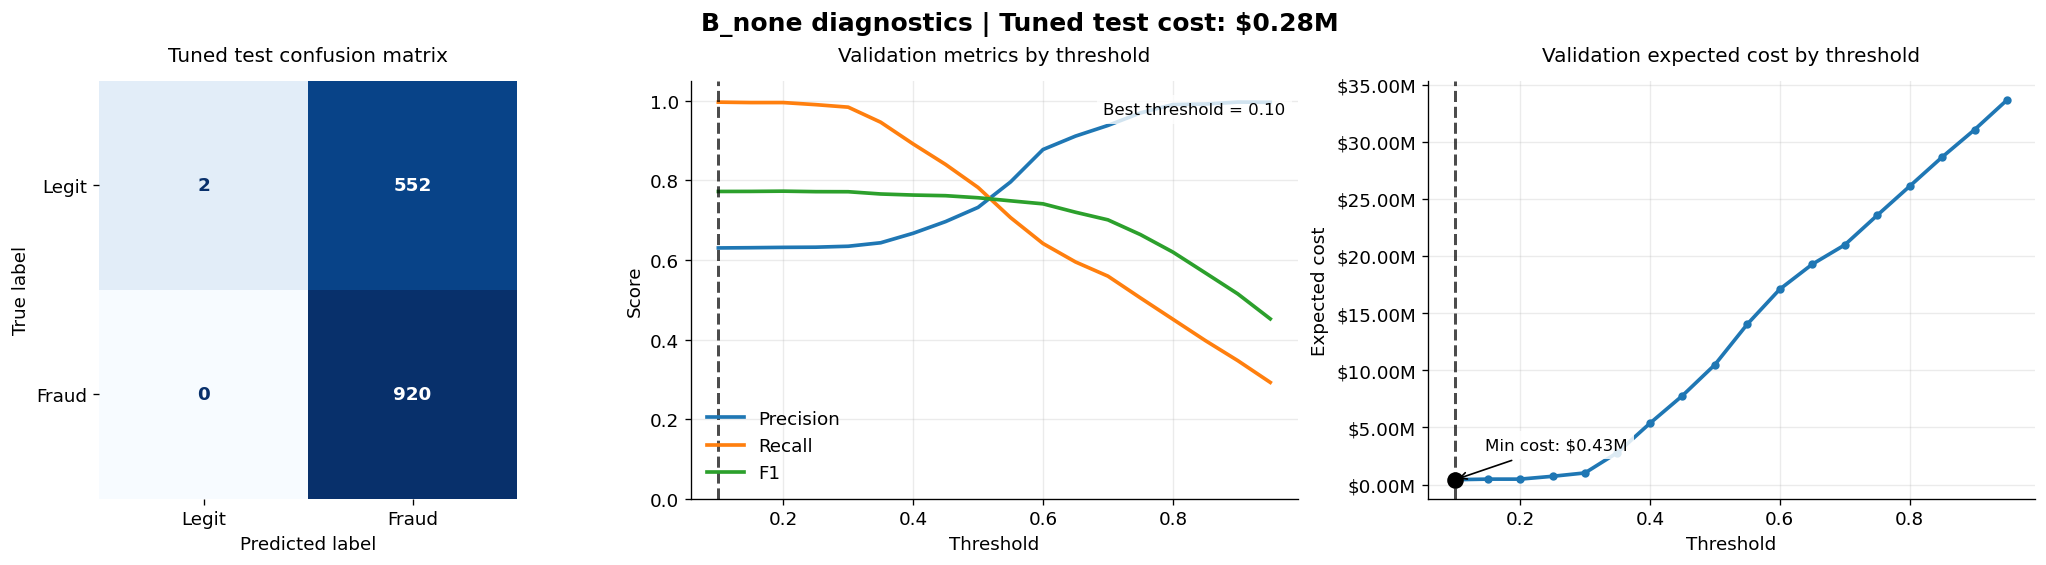

In [97]:
plot_model_diagnostics_pretty(
    cm=tuned_cm_B_none,
    threshold_results=threshold_results_B_none,
    cost_df=cost_df_B_none,
    model_name="B_none",
    save_path=RESULTS_ROOT / "diagnostics_B_none.png",
)


The B_none diagnostics show that the engineered-feature Logistic Regression model also selects a very low cost-based threshold of 0.10. At this threshold, the model detects all 920 fraud cases and produces no false negatives, giving a low tuned test cost.

However, the confusion matrix shows that the model is still highly aggressive. It correctly identifies only 2 legitimate cases and incorrectly flags 552 legitimate cases as fraud. This means the model almost always predicts fraud.

Compared with the Part A Logistic Regression models, the engineered features do not solve the main problem under cost-based tuning. The model still minimizes expected cost by sacrificing legitimate-class detection. Therefore, B_none remains a weak classifier for separating both classes, even though its expected cost is low.

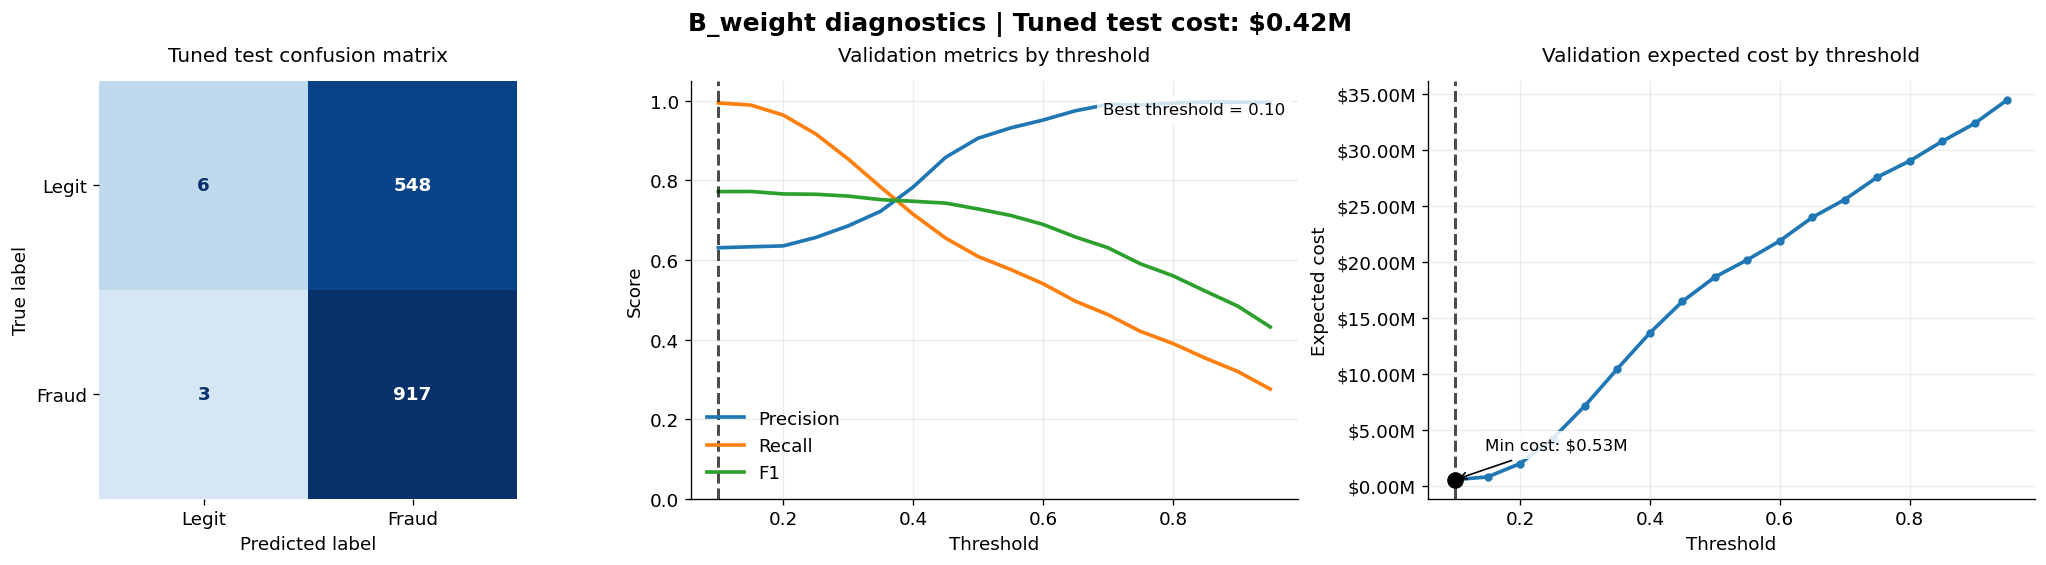

In [98]:
plot_model_diagnostics_pretty(
    cm=tuned_cm_B_weight,
    threshold_results=threshold_results_B_weight,
    cost_df=cost_df_B_weight,
    model_name="B_weight",
    save_path=RESULTS_ROOT / "diagnostics_B_weight.png",
)


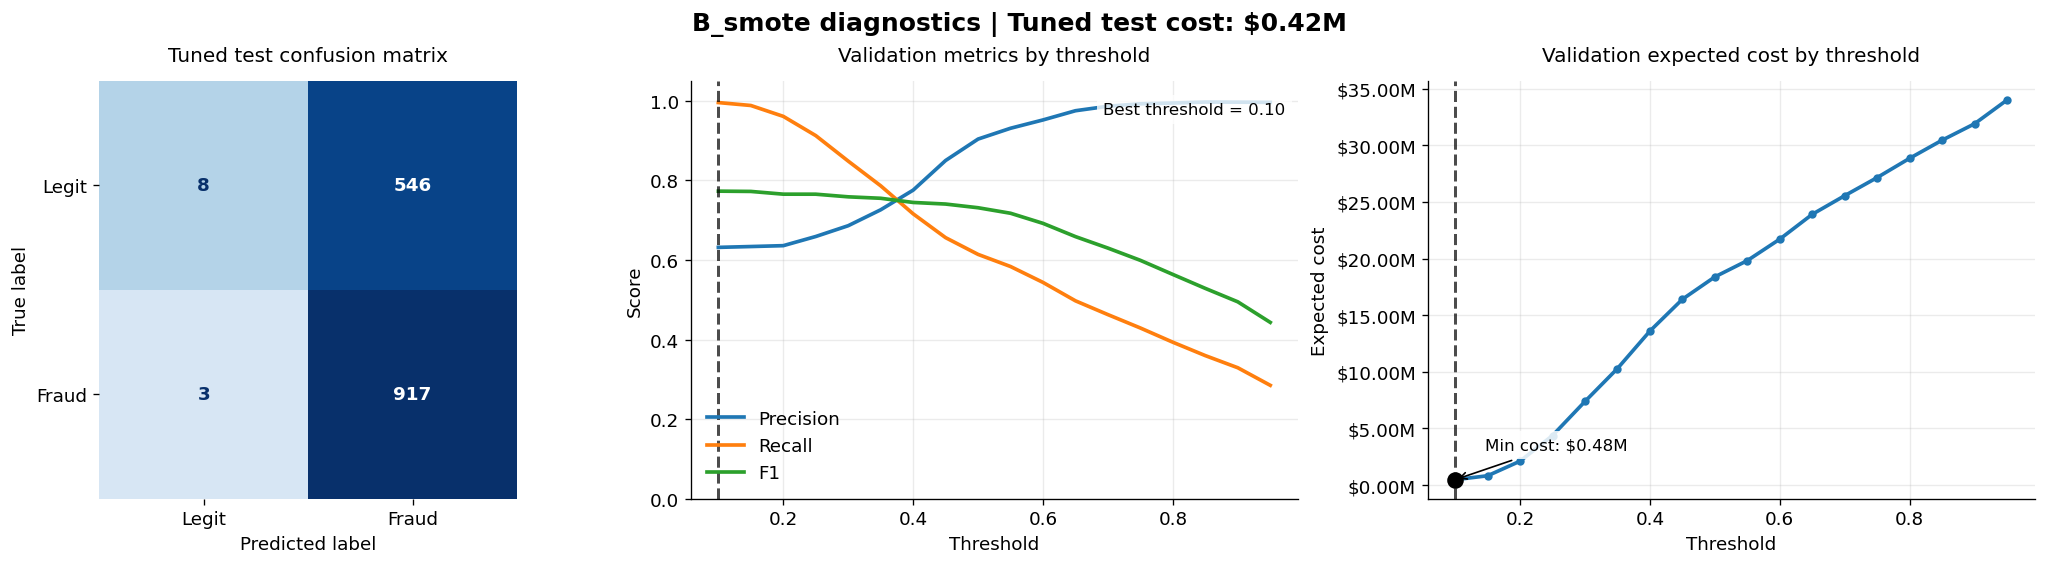

In [99]:
plot_model_diagnostics_pretty(
    cm=tuned_cm_B_smote,
    threshold_results=threshold_results_B_smote,
    cost_df=cost_df_B_smote,
    model_name="B_smote",
    save_path=RESULTS_ROOT / "diagnostics_B_smote.png",
)


The B_smote diagnostics show a slightly better cost-tuned result than the Part A Logistic Regression models, but the overall pattern is still very aggressive.

At the selected threshold of 0.10, the model detects 917 out of 920 fraud cases and misses only 3. This keeps the expected test cost relatively low at about $0.42M. However, the model also flags 546 legitimate cases as fraud and correctly identifies only 8 legitimate cases.

The validation metric plot shows that recall is very high at low thresholds, while precision and F1-score decrease as the threshold becomes too low. The cost curve still selects the lowest threshold because false negatives are much more expensive than false positives.

Overall, B_smote improves slightly compared with the raw-feature Logistic Regression variants because it keeps a few more true negatives while missing only 3 fraud cases. However, it is still an overly aggressive classifier under cost-based tuning and does not separate legitimate cases well.

## Final choice 

In [100]:
final_part_b_engineered_features = comparison_b.sort_values("tuned_expected_cost").copy()
final_part_b_engineered_features


,model,val_f1,val_roc_auc,val_pr_auc,test_f1,test_roc_auc,test_pr_auc,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
0,B_none,0.756482,0.776748,0.887079,0.757850,0.785893,0.889925,0.1,0.625000,1.000000,0.769231,276000
2,B_smote,0.731371,0.777520,0.887966,0.737321,0.787100,0.891232,0.1,0.626794,0.996739,0.769618,423000
1,B_weight,0.728302,0.777800,0.888028,0.734853,0.786338,0.890747,0.1,0.625939,0.996739,0.768973,424000


---
## Combined comparison - all six variants

Part A vs Part B: isolates the effect of feature engineering across all imbalance strategies.

In [101]:
import pandas as pd

all_variants = pd.concat([comparison_a, comparison_b], ignore_index=True)
all_variants = all_variants.sort_values("tuned_expected_cost").reset_index(drop=True)
all_variants[["model","best_threshold","tuned_test_precision",
              "tuned_test_recall","tuned_test_f1","tuned_expected_cost"]]


,model,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
0,A_weight,0.1,0.625000,1.000000,0.769231,276000
1,A_smote,0.1,0.625000,1.000000,0.769231,276000
2,B_none,0.1,0.625000,1.000000,0.769231,276000
3,A_none,0.1,0.624576,1.000000,0.768909,276500
4,B_smote,0.1,0.626794,0.996739,0.769618,423000
5,B_weight,0.1,0.625939,0.996739,0.768973,424000


In [102]:
all_variants.to_csv(RESULTS_ROOT / "comparison.csv", index=False)
print("Saved to:", RESULTS_ROOT / "comparison.csv")


Saved to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_logreg\comparison.csv


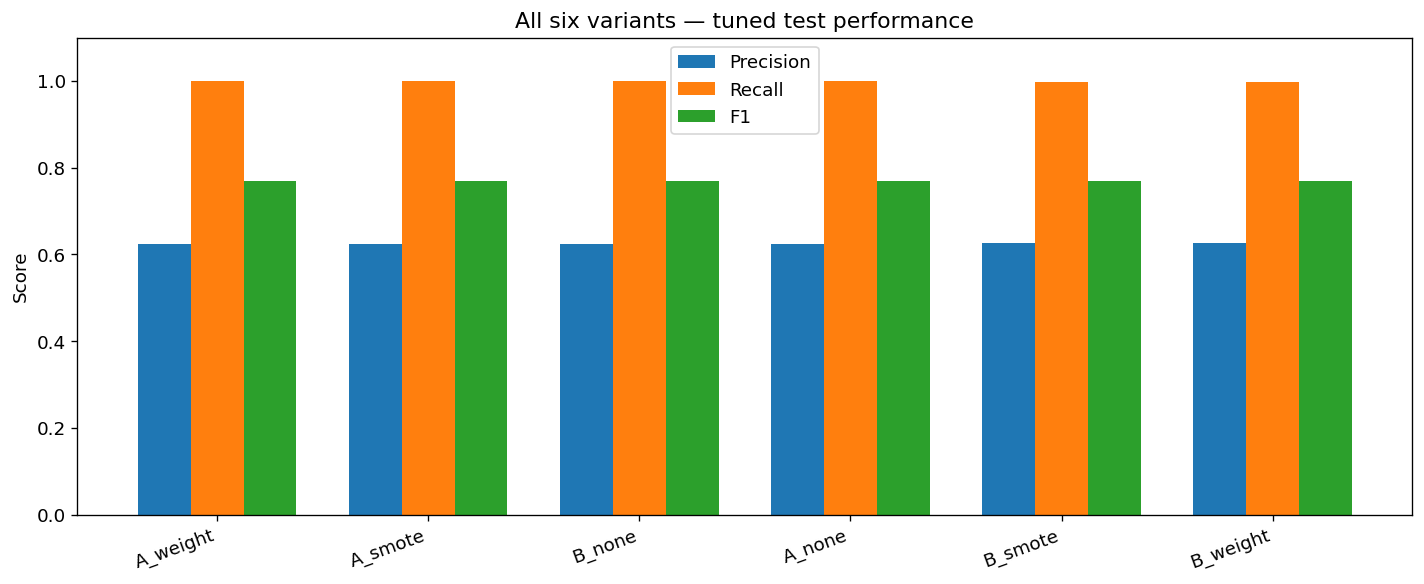

In [103]:
import numpy as np
from matplotlib.ticker import FuncFormatter

x = np.arange(len(all_variants)); width = 0.25
plt.figure(figsize=(12, 5))
for i, (metric, lbl) in enumerate([
    ("tuned_test_precision","Precision"),
    ("tuned_test_recall","Recall"),
    ("tuned_test_f1","F1"),
]):
    plt.bar(x + i*width, all_variants[metric], width, label=lbl)
plt.xticks(x + width, all_variants["model"], rotation=20, ha="right")
plt.ylabel("Score"); plt.title("All six variants — tuned test performance")
plt.legend(); plt.ylim(0, 1.1); plt.tight_layout(); plt.show()


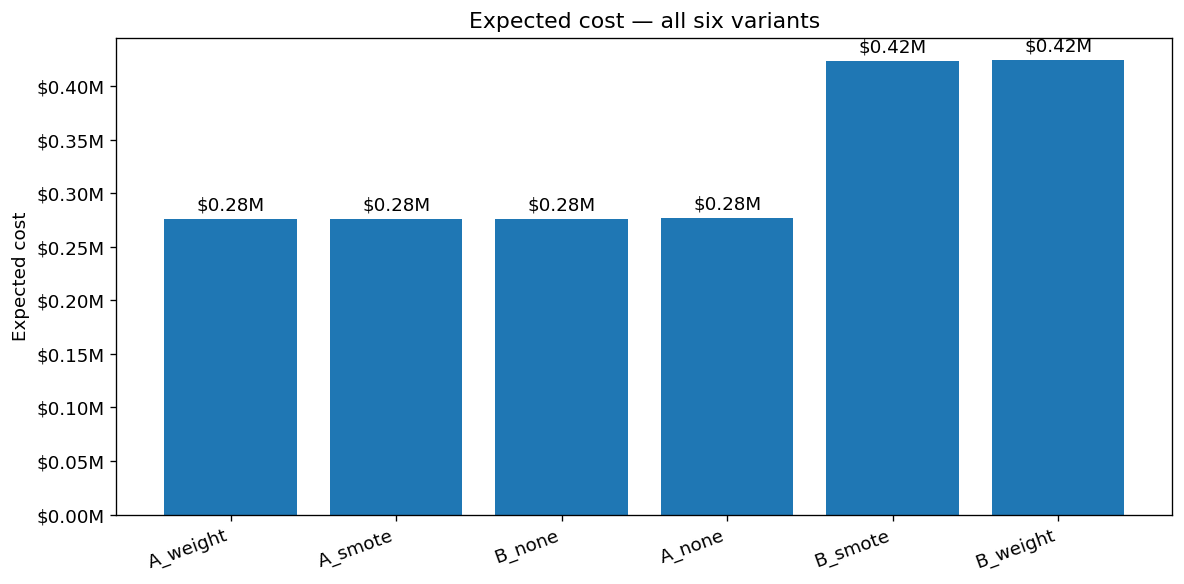

In [104]:
cost_all = all_variants.sort_values("tuned_expected_cost")
plt.figure(figsize=(10, 5))
bars = plt.bar(cost_all["model"], cost_all["tuned_expected_cost"])
plt.title("Expected cost — all six variants")
plt.ylabel("Expected cost")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.2f}M"))
plt.bar_label(bars,
    labels=[f"${v/1_000_000:.2f}M" for v in cost_all["tuned_expected_cost"]], padding=3)
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()




The expected cost comparison shows that most Logistic Regression variants achieve a similar tuned test cost of around $0.28M. The only exceptions are B_smote and B_weight, which have higher costs of around $0.42M.

This difference is mainly explained by false negatives. The lower-cost variants detect all fraud cases after cost-based tuning, while B_smote and B_weight still miss 3 fraud cases. Since each missed fraud case is assigned a much higher cost than a false positive, even a few false negatives increase the total expected cost.


## Final choice

In [1]:
final_choice_df = all_variants.sort_values("tuned_expected_cost").copy()
print("Best variant:", final_choice_df.iloc[0]["model"])
print(final_choice_df)


NameError: name 'all_variants' is not defined